# DESCOMPOSICIÓN Y ANÁLISIS DE LAS SERIES DE LA CARTERA

¡¡¡IMPORTANTE!!! Ejecutar primero el script _01_Ingesta_Limpieza.py

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics import tsaplots
import statsmodels.graphics.tsaplots as sgt
from arch import arch_model

## 1<sup>er</sup> activo: APPLE (AAPL)

In [2]:
rentabilidades = pd.read_csv('Datos/Limpios/Cartera_Rent.csv', index_col='trading_day')
aapl_rent = pd.DataFrame(rentabilidades['AAPL']*100)
aapl_rent

,AAPL
trading_day,
2020-06-03,0.450712
2020-06-04,0.577018
2020-06-05,-0.164165
2020-06-06,1.972370
2020-06-07,0.000000
...,...
2021-06-27,-0.224871
2021-06-28,0.019184
2021-06-29,1.237948


In [3]:
cartera = pd.read_csv('Datos/Limpios/Cartera_Close.csv', index_col='trading_day')
aapl = pd.DataFrame(cartera['AAPL'])
aapl

,AAPL
trading_day,
2020-06-03,80.703070
2020-06-04,81.168741
2020-06-05,81.035490
2020-06-06,82.633810
2020-06-07,82.633810
...,...
2021-06-27,133.110000
2021-06-28,133.135535
2021-06-29,134.783684


<Axes: xlabel='trading_day'>

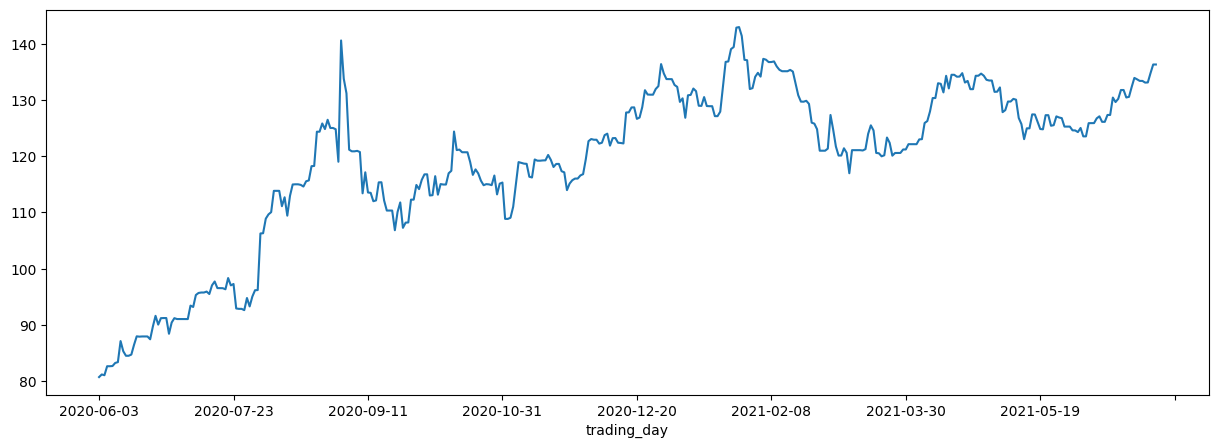

In [4]:
aapl['AAPL'].plot(figsize=(15,5))

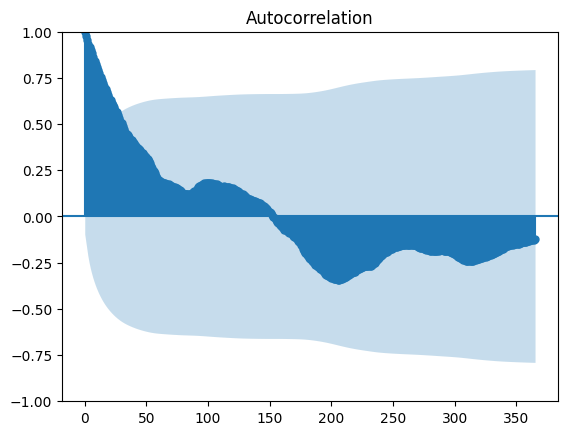

In [5]:
tsaplots.plot_acf(aapl['AAPL'], lags=365)
plt.show()

NO TIENE SENTIDO USAR SEASONAL DECOMPOSE

<Axes: xlabel='trading_day'>

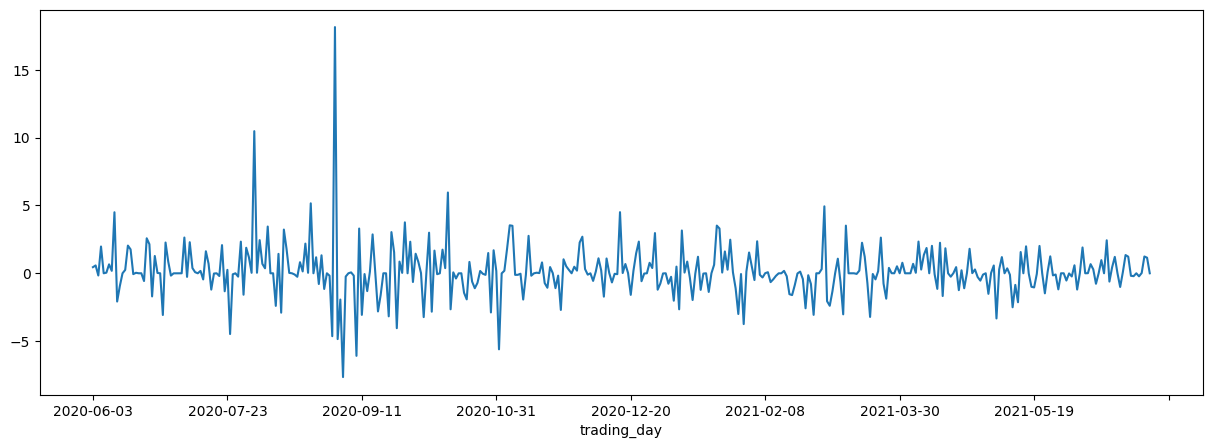

In [6]:
aapl_rent['AAPL'].plot(figsize=(15,5))

PARA OBTENER EL RESIDUO, RESTAMOS A LA SERIE CLOSE LA TENDENCIA, HACIENDO UNA PRIMERA DIFERENCIA. ESO SERÍA EQUIVALENTE A LA RENTABILIDAD, PERO NO USAMOS LA RENTABILIDAD.

<Axes: xlabel='trading_day'>

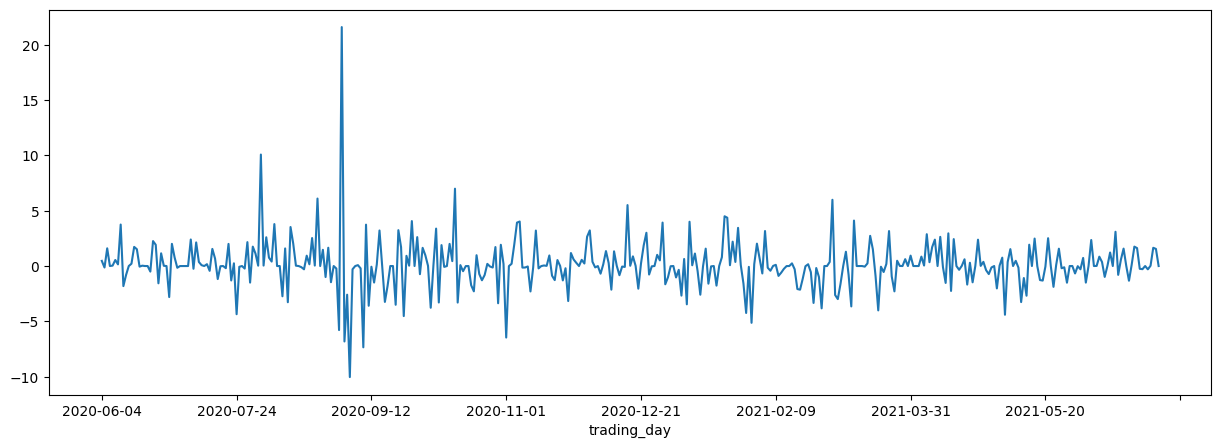

In [7]:
aapl['residuo'] = aapl['AAPL'].diff()
(aapl['residuo'].dropna()).plot(figsize=(15,5))

In [8]:
#PASAMOS TESTS DE ESTACIONARIA EN MEDIA

result = adfuller(aapl['residuo'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
print(f'Result: The series is {"not " if result[1] > 0.05 else ""}stationary')

ADF Statistic: -23.293125423659824
p-value: 0.0
Critial Values:
   1%, -3.44714244478345
Critial Values:
   5%, -2.8689414326247995
Critial Values:
   10%, -2.5707127699396084
Result: The series is stationary


In [9]:
statistic, p_value, n_lags, critical_values = kpss(aapl['residuo'].dropna())
print(f'KPSS Statistic: {statistic}')
print(f'p-value: {p_value}')
print('Critial Values:')
for key, value in critical_values.items():
    print(f'   {key} : {value}')
print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

KPSS Statistic: 0.1507363137658029
p-value: 0.1
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_4128\331088892.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(aapl['residuo'].dropna())


In [10]:
# PASAMOS TEST DE HETEROCEDASTICIDAD

lm_test = het_arch(aapl['residuo'].dropna())

print("Resultados del ARCH test:")
print(f"P-valor F: {lm_test[3]:.4f}")

Resultados del ARCH test:
P-valor F: 0.0084


ES MENOR QUE 0.05, PRESENTA HETEROCEDASTICIDAD, NO ES ESTRICTAMENTE ESTACIONARIA, ASÍ QUE MODELAMOS VOLATILIDAD

In [11]:
vol_aapl = (aapl['residuo'].dropna()).mul(aapl['residuo'].dropna())

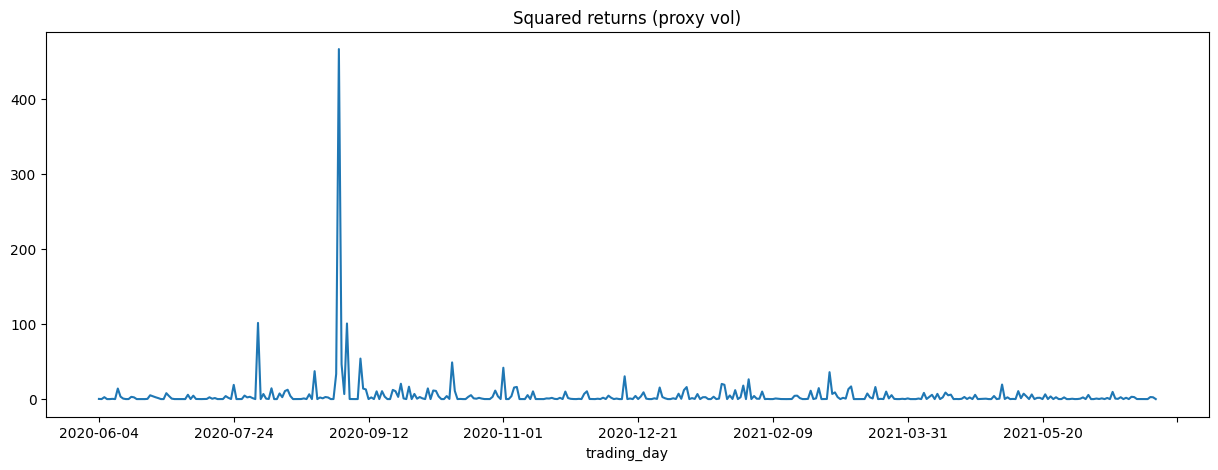

In [12]:
plt.figure(figsize=(15,5)); vol_aapl.plot(title='Squared returns (proxy vol)'); plt.show()

In [13]:
aapl.index = pd.to_datetime(aapl.index)

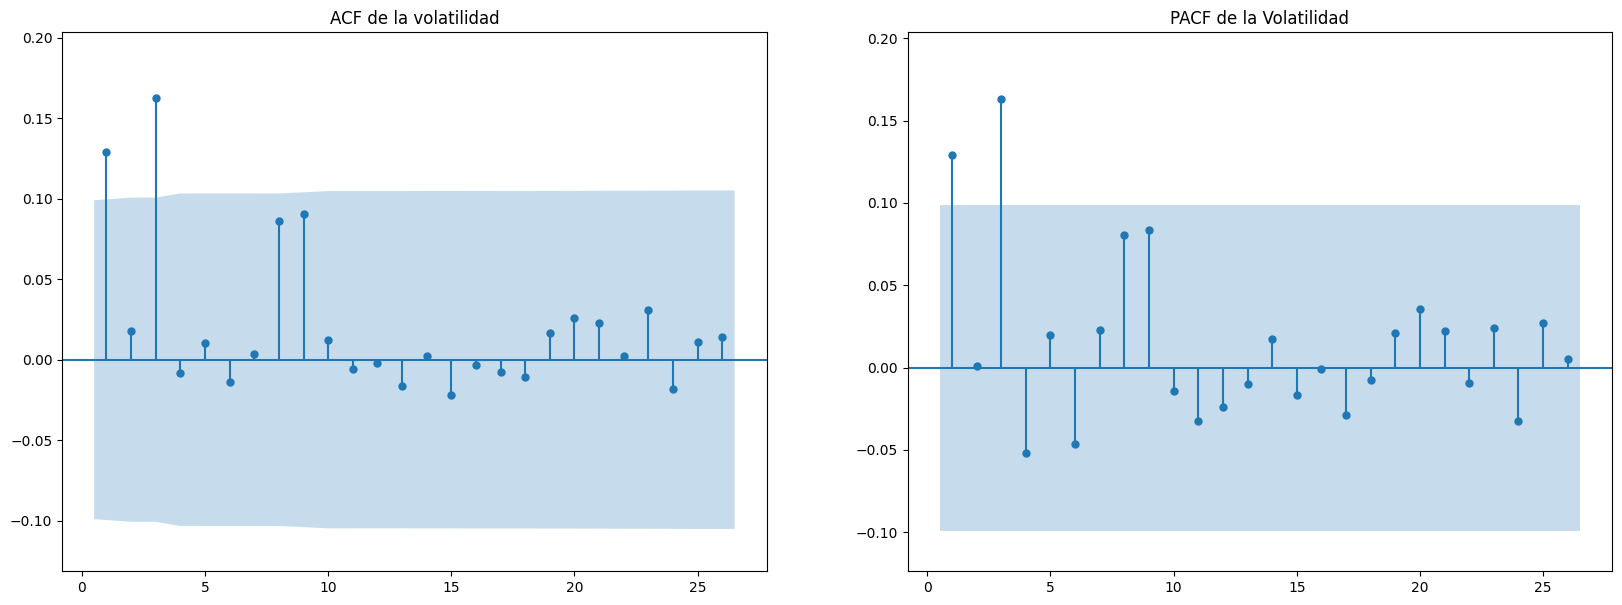

In [14]:
plt.rcParams["figure.figsize"] = (20, 7)

fig, ax = plt.subplots(1,2)

sgt.plot_acf(vol_aapl[1:],ax=ax[0],zero = False, auto_ylims=True, title="ACF de la volatilidad")
sgt.plot_pacf(vol_aapl[1:],ax=ax[1], zero = False,auto_ylims=True,title="PACF de la Volatilidad");

PROBAMOS ARCH(1), ARCH(3), GARCH(1,1), GARCH(1,3) y GARCH(3,3)

ARCH(1)

In [15]:
modelo_arch1 = arch_model(aapl.residuo[1:], vol="ARCH", p=1, mean="AR")
resultados_arch1 = modelo_arch1.fit(last_obs = aapl.index[-1])
resultados_arch1.summary()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 2631.6490310064364
Iteration:      2,   Func. Count:     11,   Neg. LLF: 884.527689712779
Iteration:      3,   Func. Count:     17,   Neg. LLF: 847.3139226919664
Iteration:      4,   Func. Count:     23,   Neg. LLF: 846.6558419377382
Iteration:      5,   Func. Count:     26,   Neg. LLF: 846.6558419376825
Optimization terminated successfully    (Exit mode 0)
            Current function value: 846.6558419377382
            Iterations: 5
            Function evaluations: 26
            Gradient evaluations: 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - ARCH Model Results                            
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -846.656
Distribution:                  Normal   AIC:                           1699.31
Method:            Maximum Likelihood   BIC:                           1711.23
                                        No. Observations:                  392
Date:                Fri, Oct 24 2025   Df Residuals:                      391
Time:                        14:23:18   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.2031      0.112      1.810  7.029e-02 [-1.682e-02,  0.423]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          3.5939      0.514      6.988  2.795e-12 [  2.586,  4.602]
alpha[1]       0.2845      0.201      1.413      0.158 [ -0.110,  0.679]
========================================================================

Covariance estimator: robust
"""

ARCH(3)

In [16]:
modelo_arch3 = arch_model(aapl.residuo[1:], vol="ARCH", p=3, mean="AR")
resultados_arch3 = modelo_arch3.fit(last_obs = aapl.index[-1])
resultados_arch3.summary()

Iteration:      1,   Func. Count:      7,   Neg. LLF: 1402.0662810232084
Iteration:      2,   Func. Count:     15,   Neg. LLF: 929.8548404374046
Iteration:      3,   Func. Count:     23,   Neg. LLF: 2489349.627344677
Iteration:      4,   Func. Count:     30,   Neg. LLF: 847.1265412662201
Iteration:      5,   Func. Count:     37,   Neg. LLF: 847.1115389327496
Iteration:      6,   Func. Count:     44,   Neg. LLF: 884.2405952874162
Iteration:      7,   Func. Count:     52,   Neg. LLF: 841.6733407750564
Iteration:      8,   Func. Count:     58,   Neg. LLF: 841.7156926350541
Iteration:      9,   Func. Count:     65,   Neg. LLF: 841.6558331131555
Iteration:     10,   Func. Count:     71,   Neg. LLF: 841.655633756046
Iteration:     11,   Func. Count:     77,   Neg. LLF: 841.6556141736764
Iteration:     12,   Func. Count:     82,   Neg. LLF: 841.6556141735299
Optimization terminated successfully    (Exit mode 0)
            Current function value: 841.6556141736764
            Iterations: 12
 

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - ARCH Model Results                            
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -841.656
Distribution:                  Normal   AIC:                           1693.31
Method:            Maximum Likelihood   BIC:                           1713.17
                                        No. Observations:                  392
Date:                Fri, Oct 24 2025   Df Residuals:                      391
Time:                        14:23:18   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.2062      0.111      1.865  6.218e-02 [-1.050e-02,  0.423]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          3.4237      0.531      6.450  1.117e-10      [  2.383,  4.464]
alpha[1]       0.2447      0.185      1.326      0.185      [ -0.117,  0.606]
alpha[2]       0.0000  3.919e-02      0.000      1.000 [-7.682e-02,7.682e-02]
alpha[3]       0.0396  2.825e-02      1.400      0.161 [-1.582e-02,9.493e-02]
=============================================================================

Covariance estimator: robust
"""

GARCH(1,1)

In [17]:
modelo_garch11 = arch_model(aapl.residuo[1:], vol="GARCH", p=1, q=1, mean='AR')
resultados_garch11 = modelo_garch11.fit(last_obs = aapl.index[-1])
resultados_garch11.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1991.5734678092667
Iteration:      2,   Func. Count:     13,   Neg. LLF: 1069.6144551202042
Iteration:      3,   Func. Count:     19,   Neg. LLF: 876.5777414005455
Iteration:      4,   Func. Count:     25,   Neg. LLF: 847.1600064169477
Iteration:      5,   Func. Count:     31,   Neg. LLF: 1121.5450649279164
Iteration:      6,   Func. Count:     38,   Neg. LLF: 872.0389136973636
Iteration:      7,   Func. Count:     44,   Neg. LLF: 841.4919128347287
Iteration:      8,   Func. Count:     49,   Neg. LLF: 841.4742647582284
Iteration:      9,   Func. Count:     54,   Neg. LLF: 841.4717613988331
Iteration:     10,   Func. Count:     59,   Neg. LLF: 841.4717230296994
Iteration:     11,   Func. Count:     64,   Neg. LLF: 841.4717207453609
Iteration:     12,   Func. Count:     68,   Neg. LLF: 841.4717207454346
Optimization terminated successfully    (Exit mode 0)
            Current function value: 841.4717207453609
            Iterations: 1

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - GARCH Model Results                           
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -841.472
Distribution:                  Normal   AIC:                           1690.94
Method:            Maximum Likelihood   BIC:                           1706.83
                                        No. Observations:                  392
Date:                Fri, Oct 24 2025   Df Residuals:                      391
Time:                        14:23:18   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
Const          0.2253  9.724e-02      2.317  2.050e-02 [3.472e-02,  0.416]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.8379      0.942      0.889      0.374   [ -1.009,  2.685]
alpha[1]       0.1875      0.191      0.983      0.325   [ -0.186,  0.561]
beta[1]        0.6606      0.299      2.210  2.710e-02 [7.476e-02,  1.246]
==========================================================================

Covariance estimator: robust
"""

GARCH(1,3)

In [18]:
modelo_garch13 = arch_model(aapl.residuo[1:], vol="GARCH", p=1, q=3, mean='AR')
resultados_garch13 = modelo_garch13.fit(last_obs = aapl.index[-1])
resultados_garch13.summary()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 1832.0182984809703
Iteration:      2,   Func. Count:     18,   Neg. LLF: 9011.161701152861
Iteration:      3,   Func. Count:     27,   Neg. LLF: 894.6954256817243
Iteration:      4,   Func. Count:     36,   Neg. LLF: 854.2325310049084
Iteration:      5,   Func. Count:     44,   Neg. LLF: 834.1103364129231
Iteration:      6,   Func. Count:     51,   Neg. LLF: 835.12782638221
Iteration:      7,   Func. Count:     59,   Neg. LLF: 832.810316239604
Iteration:      8,   Func. Count:     66,   Neg. LLF: 832.6553843114841
Iteration:      9,   Func. Count:     73,   Neg. LLF: 832.6339305563591
Iteration:     10,   Func. Count:     80,   Neg. LLF: 832.6311218695363
Iteration:     11,   Func. Count:     87,   Neg. LLF: 832.6310586298969
Iteration:     12,   Func. Count:     94,   Neg. LLF: 832.6310546583156
Iteration:     13,   Func. Count:    101,   Neg. LLF: 832.6310537972923
Optimization terminated successfully    (Exit mode 0)
            

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - GARCH Model Results                           
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -832.631
Distribution:                  Normal   AIC:                           1677.26
Method:            Maximum Likelihood   BIC:                           1701.09
                                        No. Observations:                  392
Date:                Fri, Oct 24 2025   Df Residuals:                      391
Time:                        14:23:19   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
Const          0.2198      0.109      2.024  4.294e-02 [6.987e-03,  0.433]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.4231      0.312      1.356      0.175    [ -0.188,  1.035]
alpha[1]       0.1632      0.131      1.242      0.214 [-9.422e-02,  0.421]
beta[1]        0.0000      0.173      0.000      1.000    [ -0.340,  0.340]
beta[2]        0.7623      0.113      6.730  1.695e-11    [  0.540,  0.984]
beta[3]    7.0202e-15      0.140  5.008e-14      1.000    [ -0.275,  0.275]
===========================================================================

Covariance estimator: robust
"""

GARCH(3,3)

In [19]:
modelo_garch33 = arch_model(aapl.residuo[1:], vol="GARCH", p=3, q=3, mean='AR')
resultados_garch33 = modelo_garch33.fit(last_obs = aapl.index[-1])
resultados_garch33.summary()

Iteration:      1,   Func. Count:     10,   Neg. LLF: 1567.539647473847
Iteration:      2,   Func. Count:     22,   Neg. LLF: 1573324.3136420383
Iteration:      3,   Func. Count:     32,   Neg. LLF: 1439.105637928887
Iteration:      4,   Func. Count:     43,   Neg. LLF: 847.6563093576613
Iteration:      5,   Func. Count:     53,   Neg. LLF: 846.9650217887852
Iteration:      6,   Func. Count:     63,   Neg. LLF: 840.5647643933789
Iteration:      7,   Func. Count:     73,   Neg. LLF: 835.8987463746987
Iteration:      8,   Func. Count:     82,   Neg. LLF: 835.4770560936358
Iteration:      9,   Func. Count:     91,   Neg. LLF: 834.3276877126706
Iteration:     10,   Func. Count:    100,   Neg. LLF: 833.7685501004242
Iteration:     11,   Func. Count:    109,   Neg. LLF: 833.683236691283
Iteration:     12,   Func. Count:    119,   Neg. LLF: 835.4824649049715
Iteration:     13,   Func. Count:    129,   Neg. LLF: 832.6688661024941
Iteration:     14,   Func. Count:    138,   Neg. LLF: 832.632120

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - GARCH Model Results                           
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -832.631
Distribution:                  Normal   AIC:                           1681.26
Method:            Maximum Likelihood   BIC:                           1713.03
                                        No. Observations:                  392
Date:                Fri, Oct 24 2025   Df Residuals:                      391
Time:                        14:23:19   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
Const          0.2198  9.953e-02      2.208  2.723e-02 [2.471e-02,  0.415]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.4231      0.447      0.947      0.344 [ -0.453,  1.299]
alpha[1]       0.1632      0.139      1.170      0.242 [ -0.110,  0.436]
alpha[2]       0.0000      0.143      0.000      1.000 [ -0.281,  0.281]
alpha[3]       0.0000      0.210      0.000      1.000 [ -0.411,  0.411]
beta[1]        0.0000      0.763      0.000      1.000 [ -1.495,  1.495]
beta[2]        0.7624      0.109      6.979  2.971e-12 [  0.548,  0.976]
beta[3]        0.0000      0.578      0.000      1.000 [ -1.133,  1.133]
========================================================================

Covariance estimator: robust
"""

In [20]:
arch1_resid = resultados_arch1.std_resid
arch3_resid = resultados_arch3.std_resid
garch11_resid = resultados_garch11.std_resid
garch13_resid = resultados_garch13.std_resid
garch33_resid = resultados_garch33.std_resid

In [21]:
lm_test = het_arch(arch1_resid.dropna())[3]
print(f"P-valor F de ARCH(1): {lm_test:.4f}")

lm_test = het_arch(arch3_resid.dropna())[3]
print(f"P-valor F de ARCH(3): {lm_test:.4f}")

lm_test = het_arch(garch11_resid.dropna())[3]
print(f"P-valor F de GARCH(1,1): {lm_test:.4f}")

lm_test = het_arch(garch13_resid.dropna())[3]
print(f"P-valor F de GARCH(1,3): {lm_test:.4f}")

lm_test = het_arch(garch33_resid.dropna())[3]
print(f"P-valor F de GARCH(3,3): {lm_test:.4f}")

P-valor F de ARCH(1): 0.0005
P-valor F de ARCH(3): 0.0034
P-valor F de GARCH(1,1): 0.1788
P-valor F de GARCH(1,3): 0.3265
P-valor F de GARCH(3,3): 0.3265


LOS ARCH NO CAPTURAN BIEN LA VOLATILIDAD, EL RESIDUO NO ES ESTACIONARIO. LOS GARCH EN CAMBIO, SÍ, NOS QUEDAMOS CON GARCH(1,3), ESTÁ EXPLICADO EN EL INFORME

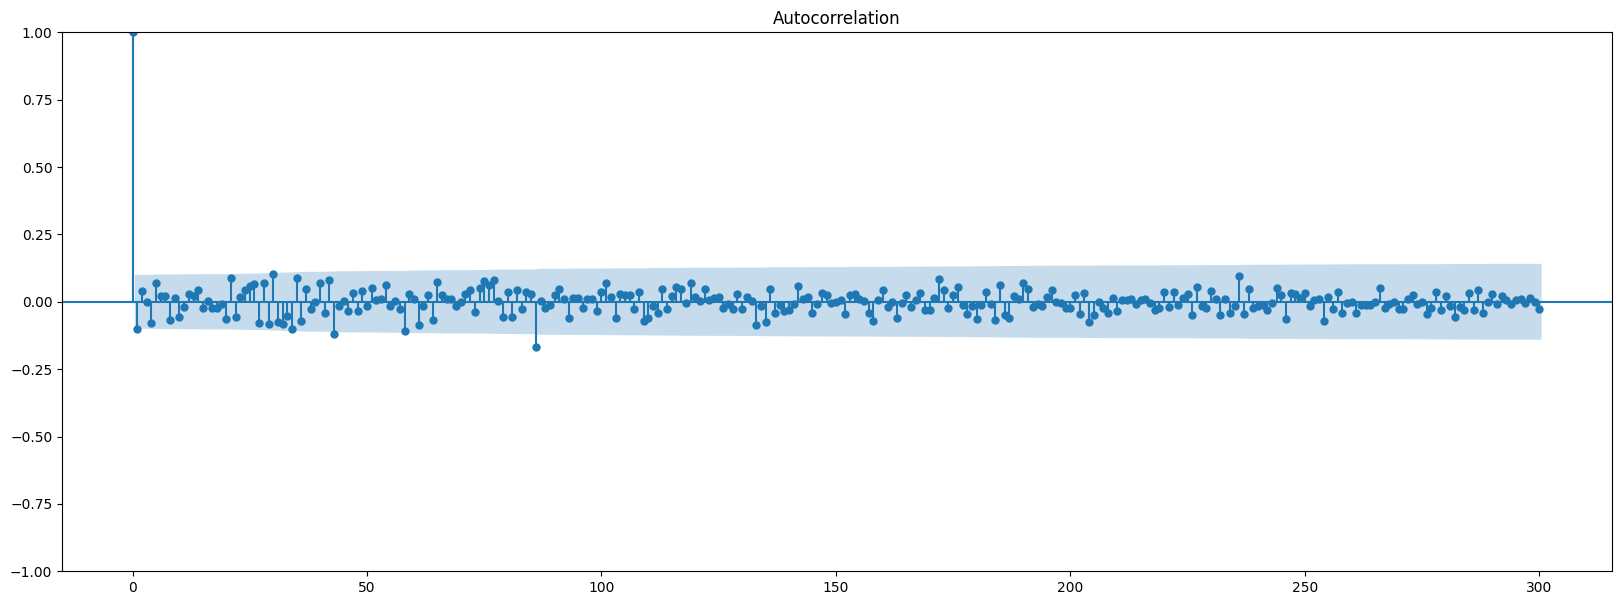

In [81]:
tsaplots.plot_acf(garch13_resid.dropna(), lags=300)
plt.show()

<Axes: xlabel='trading_day'>

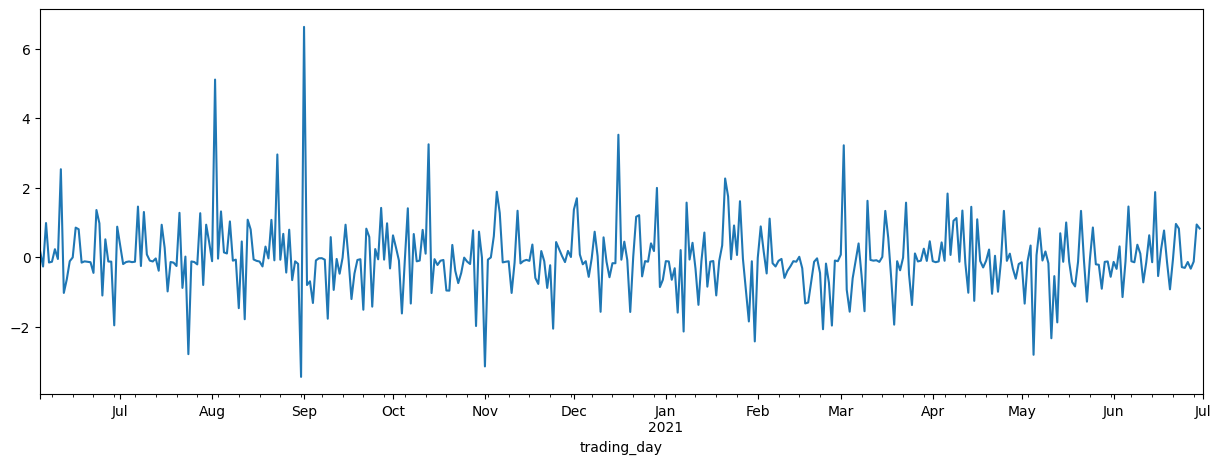

In [22]:
aapl_estacionario = garch13_resid.copy()
aapl_estacionario.plot(figsize=(15,5))

## Predicción de la volatilidad

In [53]:
index = aapl_estacionario.index
# Revierto el orden del índice para que el cero corresponda al dato más antiguo (first obs)
index=index[len(index):None:-1] 
start_loc = 0
end_loc = np.where(index >= '2021-01-01')[0].max()

In [54]:
forecasts = {}
for i in range(60):
    res = modelo_garch13.fit(first_obs = start_loc, last_obs = i + end_loc, disp = 'off')
    temp = res.forecast(horizon=1, reindex=True).variance
    fcast = temp.iloc[i + end_loc - 1]
    forecasts[fcast.name] = fcast
print(' Done!')
pred_variance_expand = pd.DataFrame(forecasts).T

 Done!


In [56]:
forecasts = {}
for i in range(60):
    res = modelo_garch13.fit(first_obs=start_loc + i, last_obs=i + end_loc, disp='off')
    temp = res.forecast(horizon=1, reindex=True).variance
    fcast = temp.iloc[i + end_loc - 1]
    forecasts[fcast.name] = fcast
print(' Done!')
pred_variance_fixed = pd.DataFrame(forecasts).T

 Done!


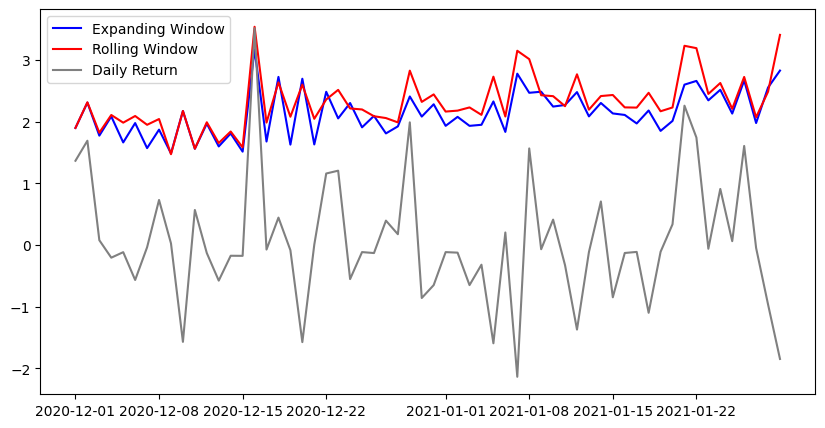

In [57]:
# Calculate volatility from variance forecast with an expanding window
pred_vol_expand = np.sqrt(pred_variance_expand)

# Calculate volatility from variance forecast with a fixed rolling window
pred_vol_fixedwin = np.sqrt(pred_variance_fixed)

# Plot results
plt.figure(figsize=(10,5))

# Plot volatility forecast with an expanding window
plt.plot(pred_vol_expand, color = 'blue', label='Expanding Window')

# Plot volatility forecast with a fixed rolling window
plt.plot(pred_vol_fixedwin, color = 'red', label='Rolling Window')

plt.plot(aapl_estacionario.loc[pred_variance_expand.index], color = 'grey', label='Daily Return')

plt.legend()
plt.show()

## 2<sup>o</sup> activo: MICROSOFT (MSFT)

In [58]:
msft_rent = pd.DataFrame(rentabilidades['MSFT']*100)
msft_rent

,MSFT
trading_day,
2020-06-03,0.000000
2020-06-04,1.381091
2020-06-05,-1.311787
2020-06-06,-0.004631
2020-06-07,0.000000
...,...
2021-06-27,-0.614588
2021-06-28,0.039513
2021-06-29,1.353238


In [59]:
msft = pd.DataFrame(cartera['MSFT'])
msft

,MSFT
trading_day,
2020-06-03,182.834884
2020-06-04,185.360000
2020-06-05,182.928472
2020-06-06,182.920000
2020-06-07,182.920000
...,...
2021-06-27,265.020000
2021-06-28,265.124717
2021-06-29,268.712484


<Axes: xlabel='trading_day'>

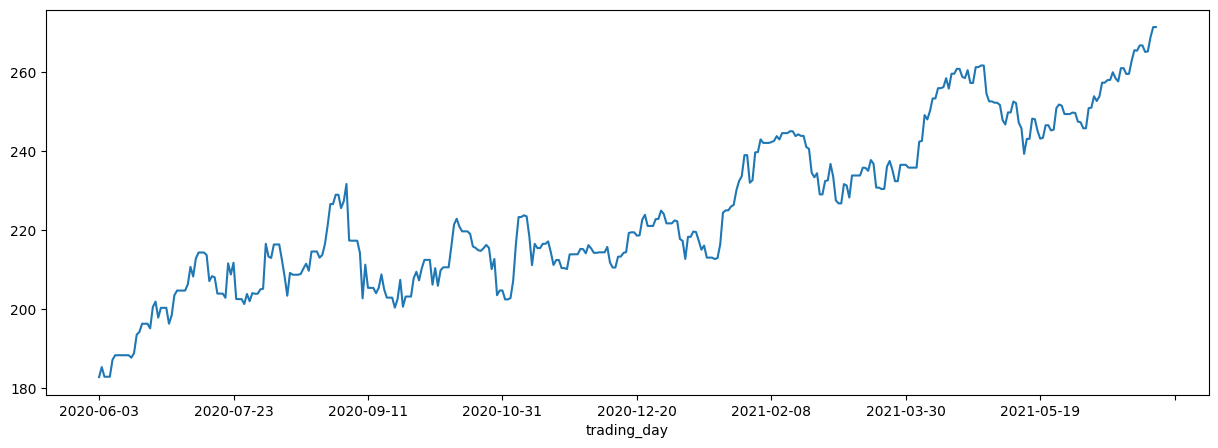

In [60]:
msft['MSFT'].plot(figsize=(15,5))

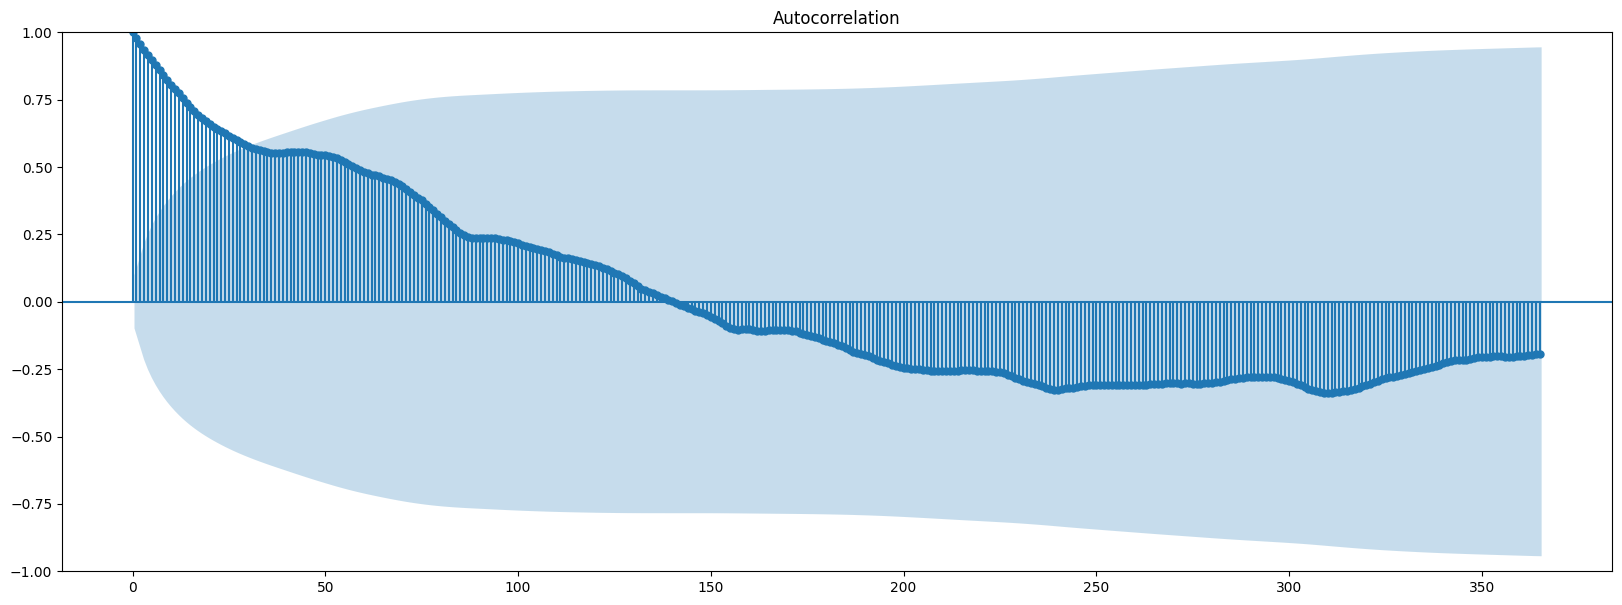

In [61]:
tsaplots.plot_acf(msft['MSFT'], lags=365)
plt.show()

NO TIENE SENTIDO USAR SEASONAL DECOMPOSE

<Axes: xlabel='trading_day'>

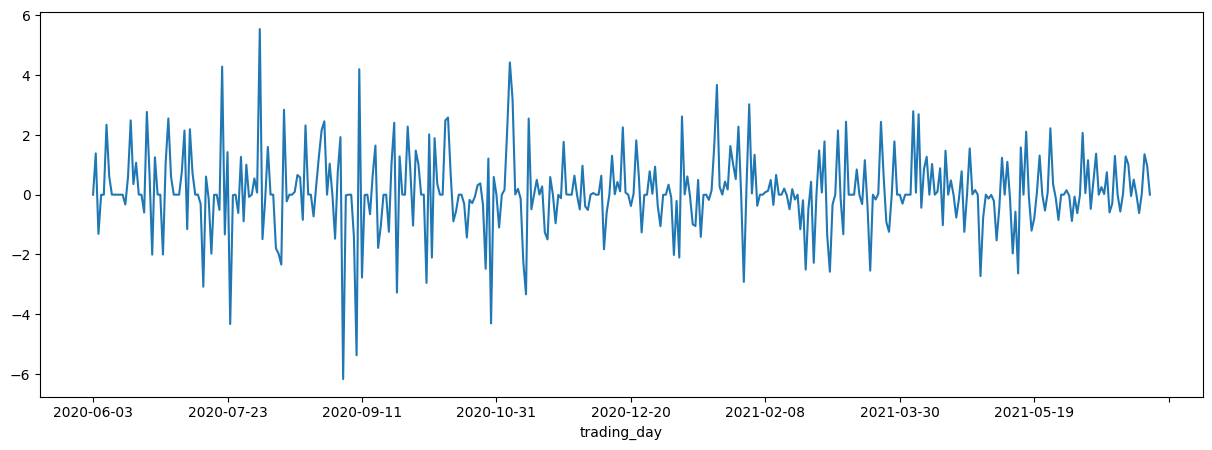

In [62]:
msft_rent['MSFT'].plot(figsize=(15,5))

<Axes: xlabel='trading_day'>

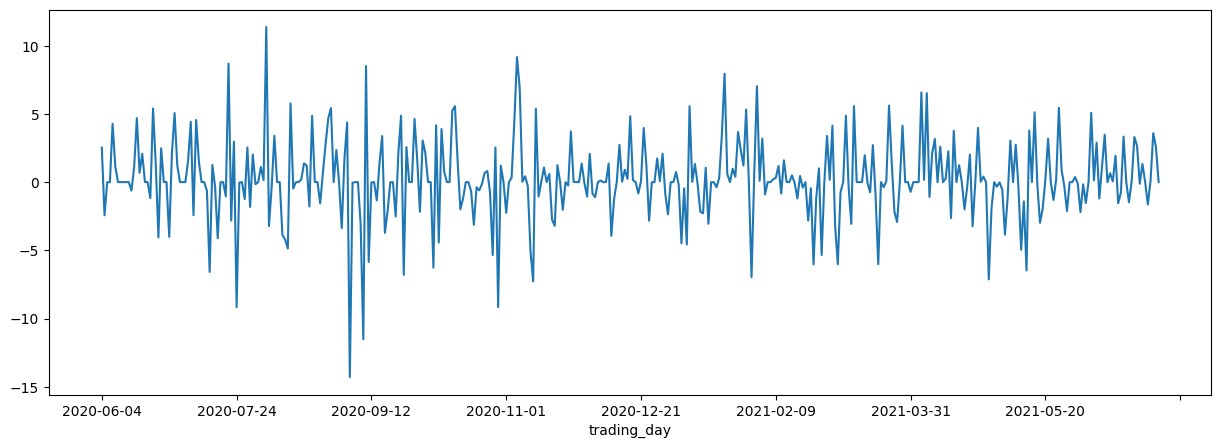

In [63]:
msft['residuo'] = msft['MSFT'].diff()
(msft['residuo'].dropna()).plot(figsize=(15,5))

In [64]:
#PASAMOS TESTS DE ESTACIONARIA EN MEDIA

result = adfuller(msft['residuo'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
print(f'Result: The series is {"not " if result[1] > 0.05 else ""}stationary')

ADF Statistic: -21.18601727759726
p-value: 0.0
Critial Values:
   1%, -3.44714244478345
Critial Values:
   5%, -2.8689414326247995
Critial Values:
   10%, -2.5707127699396084
Result: The series is stationary


In [65]:
statistic, p_value, n_lags, critical_values = kpss(msft['residuo'].dropna())
print(f'KPSS Statistic: {statistic}')
print(f'p-value: {p_value}')
print('Critial Values:')
for key, value in critical_values.items():
    print(f'   {key} : {value}')
print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

KPSS Statistic: 0.04080359470577116
p-value: 0.1
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_4128\4104638062.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(msft['residuo'].dropna())


In [66]:
# PASAMOS TEST DE HETEROCEDASTICIDAD

lm_test = het_arch(msft['residuo'].dropna())

print("Resultados del ARCH test:")
print(f"P-valor F: {lm_test[3]:.4f}")

Resultados del ARCH test:
P-valor F: 0.0011


NO ES ESTRICTAMENTE ESTACIONARIA, VAMOS A MODELIZAR LA VOLATILIDAD

In [67]:
vol_msft = msft['residuo'].dropna().mul(msft['residuo'].dropna())

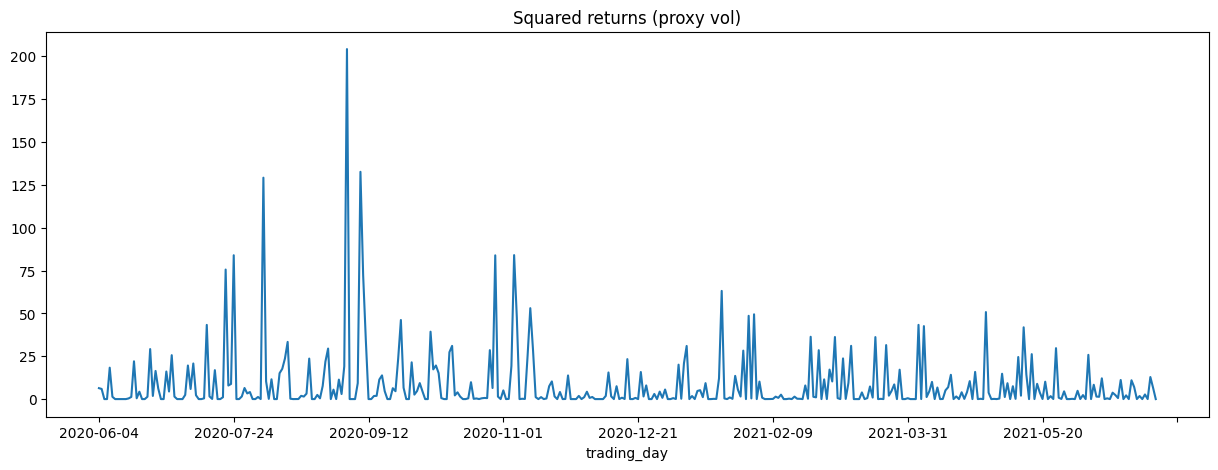

In [68]:
plt.figure(figsize=(15,5)); vol_msft.plot(title='Squared returns (proxy vol)'); plt.show()

In [69]:
msft.index = pd.to_datetime(msft.index)

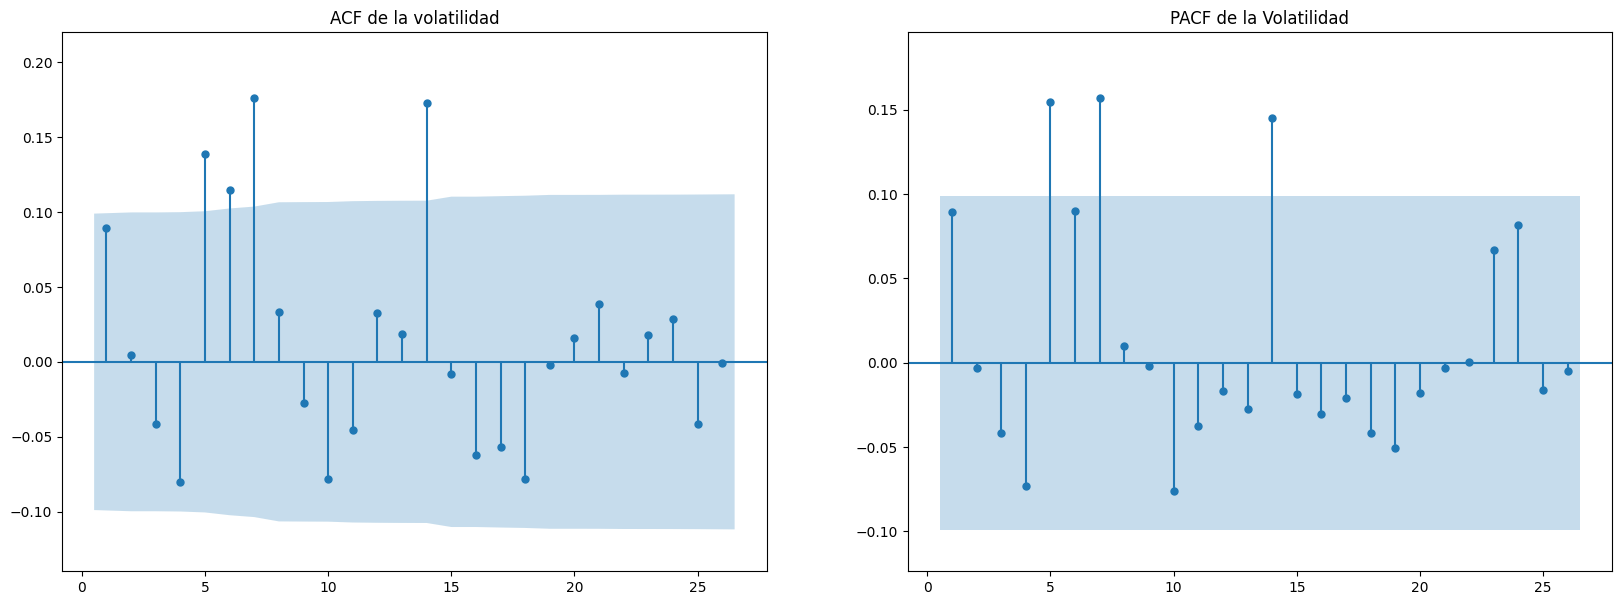

In [70]:
plt.rcParams["figure.figsize"] = (20, 7)

fig, ax = plt.subplots(1,2)

sgt.plot_acf(vol_msft[1:],ax=ax[0],zero = False, auto_ylims=True, title="ACF de la volatilidad")
sgt.plot_pacf(vol_msft[1:],ax=ax[1], zero = False,auto_ylims=True,title="PACF de la Volatilidad");

PROBAMOS ARCH(5), ARCH(7), GARCH(5,5), GARCH(5,7) y GARCH(7,7)

ARCH(5)

In [71]:
modelo_arch5 = arch_model(msft.residuo[1:], vol="ARCH", p=5, mean="AR")
resultados_arch5 = modelo_arch5.fit(last_obs = msft.index[-1])
resultados_arch5.summary()

Iteration:      1,   Func. Count:      9,   Neg. LLF: 1020.8985443327024
Iteration:      2,   Func. Count:     19,   Neg. LLF: 1406.9177239167882
Iteration:      3,   Func. Count:     29,   Neg. LLF: 978.0523082412633
Iteration:      4,   Func. Count:     38,   Neg. LLF: 1447.328473882838
Iteration:      5,   Func. Count:     48,   Neg. LLF: 971.3031921928845
Iteration:      6,   Func. Count:     56,   Neg. LLF: 977.8189292552321
Iteration:      7,   Func. Count:     66,   Neg. LLF: 975.7531789576991
Iteration:      8,   Func. Count:     75,   Neg. LLF: 971.1394456490463
Iteration:      9,   Func. Count:     83,   Neg. LLF: 971.1394336881195
Iteration:     10,   Func. Count:     90,   Neg. LLF: 971.1394336879905
Optimization terminated successfully    (Exit mode 0)
            Current function value: 971.1394336881195
            Iterations: 10
            Function evaluations: 90
            Gradient evaluations: 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - ARCH Model Results                            
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -971.139
Distribution:                  Normal   AIC:                           1956.28
Method:            Maximum Likelihood   BIC:                           1984.08
                                        No. Observations:                  392
Date:                Fri, Oct 24 2025   Df Residuals:                      391
Time:                        14:33:29   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
Const          0.2059      0.300      0.685      0.493 [ -0.383,  0.795]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          7.1737      4.892      1.466      0.143    [ -2.414, 16.761]
alpha[1]       0.1104      0.146      0.756      0.450    [ -0.176,  0.397]
alpha[2]   2.6877e-03      0.404  6.650e-03      0.995    [ -0.789,  0.795]
alpha[3]   3.6971e-11      0.238  1.555e-10      1.000    [ -0.466,  0.466]
alpha[4]   9.9898e-11      0.187  5.347e-10      1.000    [ -0.366,  0.366]
alpha[5]       0.0413  5.979e-02      0.690      0.490 [-7.591e-02,  0.158]
===========================================================================

Covariance estimator: robust
"""

ARCH(7)

In [72]:
modelo_arch7 = arch_model(msft.residuo[1:], vol="ARCH", p=7, mean="AR")
resultados_arch7 = modelo_arch7.fit(last_obs = msft.index[-1])
resultados_arch7.summary()

Iteration:      1,   Func. Count:     11,   Neg. LLF: 1008.309809498153
Iteration:      2,   Func. Count:     22,   Neg. LLF: 1211.3607677554376
Iteration:      3,   Func. Count:     33,   Neg. LLF: 1015.5552954630697
Iteration:      4,   Func. Count:     45,   Neg. LLF: 218360357.89367658
Iteration:      5,   Func. Count:     56,   Neg. LLF: 43175.01765132224
Iteration:      6,   Func. Count:     67,   Neg. LLF: 1981.2299558876014
Iteration:      7,   Func. Count:     78,   Neg. LLF: 959.0683334015587
Iteration:      8,   Func. Count:     89,   Neg. LLF: 1485.3873451640234
Iteration:      9,   Func. Count:    100,   Neg. LLF: 950.0148263515157
Iteration:     10,   Func. Count:    110,   Neg. LLF: 951.3984541205215
Iteration:     11,   Func. Count:    121,   Neg. LLF: 949.8286129143537
Iteration:     12,   Func. Count:    131,   Neg. LLF: 949.8013924960694
Iteration:     13,   Func. Count:    141,   Neg. LLF: 949.7997535509967
Iteration:     14,   Func. Count:    151,   Neg. LLF: 949.7

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - ARCH Model Results                            
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -949.800
Distribution:                  Normal   AIC:                           1917.60
Method:            Maximum Likelihood   BIC:                           1953.34
                                        No. Observations:                  392
Date:                Fri, Oct 24 2025   Df Residuals:                      391
Time:                        14:34:04   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
Const          0.1108      0.155      0.716      0.474 [ -0.192,  0.414]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          3.1037      1.516      2.047  4.065e-02      [  0.132,  6.075]
alpha[1]   1.7379e-10  4.433e-02  3.920e-09      1.000 [-8.689e-02,8.689e-02]
alpha[2]       0.1685      0.125      1.353      0.176   [-7.557e-02,  0.413]
alpha[3]   4.5551e-10      0.137  3.321e-09      1.000      [ -0.269,  0.269]
alpha[4]   1.0078e-09  5.884e-02  1.713e-08      1.000      [ -0.115,  0.115]
alpha[5]       0.0545  3.328e-02      1.637      0.102   [-1.074e-02,  0.120]
alpha[6]       0.0374  8.638e-02      0.433      0.665      [ -0.132,  0.207]
alpha[7]       0.5642      0.247      2.281  2.255e-02    [7.939e-02,  1.049]
=============================================================================

Covariance estimator: robust
"""

GARCH(5,5)

In [73]:
modelo_garch55 = arch_model(msft.residuo[1:], vol="GARCH", p=5, q=5, mean='AR')
resultados_garch55 = modelo_garch55.fit(last_obs = msft.index[-1])
resultados_garch55.summary()

Iteration:      1,   Func. Count:     14,   Neg. LLF: 1111.539694800083
Iteration:      2,   Func. Count:     29,   Neg. LLF: 1628.1703995210528
Iteration:      3,   Func. Count:     44,   Neg. LLF: 1046.0581453900702
Iteration:      4,   Func. Count:     59,   Neg. LLF: 1054.8091165296291
Iteration:      5,   Func. Count:     74,   Neg. LLF: 974.5966358925488
Iteration:      6,   Func. Count:     88,   Neg. LLF: 980.4258626765028
Iteration:      7,   Func. Count:    102,   Neg. LLF: 970.9372226502295
Iteration:      8,   Func. Count:    116,   Neg. LLF: 976.4163092837593
Iteration:      9,   Func. Count:    130,   Neg. LLF: 973.8931987174599
Iteration:     10,   Func. Count:    144,   Neg. LLF: 966.8645066062479
Iteration:     11,   Func. Count:    158,   Neg. LLF: 965.4950881037222
Iteration:     12,   Func. Count:    171,   Neg. LLF: 975.1505660307796
Iteration:     13,   Func. Count:    186,   Neg. LLF: 965.4184480630834
Iteration:     14,   Func. Count:    200,   Neg. LLF: 965.249

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - GARCH Model Results                           
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -965.043
Distribution:                  Normal   AIC:                           1954.09
Method:            Maximum Likelihood   BIC:                           2001.74
                                        No. Observations:                  392
Date:                Fri, Oct 24 2025   Df Residuals:                      391
Time:                        14:34:47   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.2219      0.161      1.377      0.168 [-9.384e-02,  0.538]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          1.5225      1.579      0.964      0.335    [ -1.573,  4.618]
alpha[1]   9.8436e-03      0.200  4.918e-02      0.961    [ -0.382,  0.402]
alpha[2]       0.2495      0.283      0.882      0.378    [ -0.305,  0.804]
alpha[3]   1.2752e-09      0.113  1.133e-08      1.000    [ -0.221,  0.221]
alpha[4]   1.6723e-09      0.371  4.513e-09      1.000    [ -0.726,  0.726]
alpha[5]       0.0336  5.446e-02      0.617      0.537 [-7.313e-02,  0.140]
beta[1]    1.0285e-08      0.439  2.342e-08      1.000    [ -0.861,  0.861]
beta[2]    1.0407e-08      0.299  3.477e-08      1.000    [ -0.587,  0.587]
beta[3]    1.0263e-08      0.335  3.064e-08      1.000    [ -0.657,  0.657]
beta[4]        0.1006      0.372      0.271      0.787    [ -0.628,  0.829]
beta[5]        0.4572      0.266      1.722  8.513e-02 [-6.328e-02,  0.978]
===========================================================================

Covariance estimator: robust
"""

GARCH(5,7)

In [79]:
modelo_garch57 = arch_model(msft.residuo[1:], vol="GARCH", p=5, q=7, mean='AR')
resultados_garch57 = modelo_garch57.fit(last_obs = msft.index[-1])
resultados_garch57.summary()

Iteration:      1,   Func. Count:     16,   Neg. LLF: 1106.8148237154155
Iteration:      2,   Func. Count:     33,   Neg. LLF: 90140.19620451878
Iteration:      3,   Func. Count:     50,   Neg. LLF: 1102.339364137116
Iteration:      4,   Func. Count:     67,   Neg. LLF: 1024.7823740731276
Iteration:      5,   Func. Count:     83,   Neg. LLF: 974.2909347721611
Iteration:      6,   Func. Count:     99,   Neg. LLF: 967.6534355928193
Iteration:      7,   Func. Count:    114,   Neg. LLF: 1062.9203342746073
Iteration:      8,   Func. Count:    130,   Neg. LLF: 985.1343453793294
Iteration:      9,   Func. Count:    146,   Neg. LLF: 961.2218100616868
Iteration:     10,   Func. Count:    161,   Neg. LLF: 1018.1479322331323
Iteration:     11,   Func. Count:    177,   Neg. LLF: 960.2415223099017
Iteration:     12,   Func. Count:    192,   Neg. LLF: 960.0284196186786
Iteration:     13,   Func. Count:    207,   Neg. LLF: 959.7084760598452
Iteration:     14,   Func. Count:    222,   Neg. LLF: 959.67

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - GARCH Model Results                           
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -959.658
Distribution:                  Normal   AIC:                           1947.32
Method:            Maximum Likelihood   BIC:                           2002.91
                                        No. Observations:                  392
Date:                Fri, Oct 24 2025   Df Residuals:                      391
Time:                        15:02:44   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
Const          0.1821      0.157      1.161      0.246 [ -0.125,  0.490]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.2909      0.451      0.645      0.519    [ -0.592,  1.174]
alpha[1]       0.0121      0.110      0.110      0.913    [ -0.204,  0.228]
alpha[2]       0.2847  9.641e-02      2.953  3.150e-03  [9.571e-02,  0.474]
alpha[3]   5.8255e-11      0.145  4.026e-10      1.000    [ -0.284,  0.284]
alpha[4]   1.0843e-10      0.114  9.503e-10      1.000    [ -0.224,  0.224]
alpha[5]       0.0222      0.145      0.153      0.878    [ -0.261,  0.306]
beta[1]    4.8762e-11      0.273  1.789e-10      1.000    [ -0.534,  0.534]
beta[2]    4.1786e-11  8.962e-02  4.662e-10      1.000    [ -0.176,  0.176]
beta[3]    3.4667e-11      0.495  7.009e-11      1.000    [ -0.969,  0.969]
beta[4]    1.8281e-11      0.149  1.230e-10      1.000    [ -0.291,  0.291]
beta[5]        0.3612      0.266      1.356      0.175    [ -0.161,  0.883]
beta[6]    3.9061e-11      0.296  1.320e-10      1.000    [ -0.580,  0.580]
beta[7]        0.3199      0.166      1.922  5.457e-02 [-6.270e-03,  0.646]
===========================================================================

Covariance estimator: robust
"""

GARCH(7,7)

In [136]:
modelo_garch77 = arch_model(msft.residuo[1:], vol="GARCH", p=7, q=7, mean='AR', dist='t')
resultados_garch77 = modelo_garch77.fit(last_obs = msft.index[-1])
resultados_garch77.summary()

Iteration:      1,   Func. Count:     19,   Neg. LLF: 1323.7187719314602
Iteration:      2,   Func. Count:     38,   Neg. LLF: 1861.637019409613
Iteration:      3,   Func. Count:     57,   Neg. LLF: 2161.5143707910106
Iteration:      4,   Func. Count:     76,   Neg. LLF: 1350.5651965038116
Iteration:      5,   Func. Count:     95,   Neg. LLF: 1294.7967059613788
Iteration:      6,   Func. Count:    114,   Neg. LLF: 1112.4286947308453
Iteration:      7,   Func. Count:    133,   Neg. LLF: 1104.2233844662978
Iteration:      8,   Func. Count:    152,   Neg. LLF: 1021.4566653449937
Iteration:      9,   Func. Count:    171,   Neg. LLF: 2404.3931117125676
Iteration:     10,   Func. Count:    191,   Neg. LLF: 1055.3948881180931
Iteration:     11,   Func. Count:    210,   Neg. LLF: 1082.0176101384127
Iteration:     12,   Func. Count:    229,   Neg. LLF: 1091.2058232372092
Iteration:     13,   Func. Count:    248,   Neg. LLF: 1085.9589962747466
Iteration:     14,   Func. Count:    267,   Neg. LLF

<class 'statsmodels.iolib.summary.Summary'>
"""
                              AR - GARCH Model Results                              
====================================================================================
Dep. Variable:                      residuo   R-squared:                       0.000
Mean Model:                              AR   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -746.763
Distribution:      Standardized Student's t   AIC:                           1527.53
Method:                  Maximum Likelihood   BIC:                           1595.04
                                              No. Observations:                  392
Date:                      Sat, Oct 25 2025   Df Residuals:                      391
Time:                              12:57:51   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const      3.3622e-03  2.327e-03      1.445      0.148 [-1.198e-03,7.922e-03]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      8.1547e-04  4.420e-03      0.185      0.854 [-7.847e-03,9.478e-03]
alpha[1]   7.7655e-06  1.677e-04  4.632e-02      0.963 [-3.208e-04,3.364e-04]
alpha[2]   1.2023e-05  1.063e-04      0.113      0.910 [-1.962e-04,2.203e-04]
alpha[3]   5.9635e-06  2.976e-04  2.004e-02      0.984 [-5.774e-04,5.893e-04]
alpha[4]   4.0138e-05  1.833e-04      0.219      0.827 [-3.191e-04,3.994e-04]
alpha[5]   1.4391e-03  2.421e-03      0.594      0.552 [-3.306e-03,6.184e-03]
alpha[6]   1.5416e-04  2.554e-04      0.604      0.546 [-3.464e-04,6.547e-04]
alpha[7]       0.4022  7.149e-02      5.626  1.849e-08      [  0.262,  0.542]
beta[1]    8.8425e-06  3.257e-04  2.715e-02      0.978 [-6.295e-04,6.471e-04]
beta[2]    6.7320e-06  1.909e-04  3.527e-02      0.972 [-3.674e-04,3.808e-04]
beta[3]    1.4501e-05  3.700e-04  3.919e-02      0.969 [-7.108e-04,7.398e-04]
beta[4]    1.1252e-05  2.056e-04  5.472e-02      0.956 [-3.918e-04,4.143e-04]
beta[5]    5.8290e-05  2.298e-03  2.537e-02      0.980 [-4.445e-03,4.562e-03]
beta[6]    4.9168e-05  2.806e-04      0.175      0.861 [-5.009e-04,5.992e-04]
beta[7]        0.5953  7.112e-02      8.372  5.689e-17      [  0.456,  0.735]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             2.9798      0.189     15.745  7.471e-56 [  2.609,  3.351]
========================================================================

Covariance estimator: robust
"""

In [137]:
arch5_resid = resultados_arch5.std_resid
arch7_resid = resultados_arch7.std_resid
garch55_resid = resultados_garch55.std_resid
garch57_resid = resultados_garch57.std_resid
garch77_resid = resultados_garch77.std_resid

In [138]:
lm_test = het_arch(arch5_resid.dropna())[3]
print(f"P-valor F de ARCH(5): {lm_test:.4f}")

lm_test = het_arch(arch7_resid.dropna())[3]
print(f"P-valor F de ARCH(7): {lm_test:.4f}")

lm_test = het_arch(garch55_resid.dropna())[3]
print(f"P-valor F de GARCH(5,5): {lm_test:.4f}")

lm_test = het_arch(garch57_resid.dropna())[3]
print(f"P-valor F de GARCH(5,7): {lm_test:.4f}")

lm_test = het_arch(garch77_resid.dropna())[3]
print(f"P-valor F de GARCH(7,7): {lm_test:.4f}")

P-valor F de ARCH(5): 0.1898
P-valor F de ARCH(7): 0.5057
P-valor F de GARCH(5,5): 0.4224
P-valor F de GARCH(5,7): 0.1680
P-valor F de GARCH(7,7): 0.8764


NOS QUEDAMOS CON GARCH(5,7), ESTÁ EXPLICADO EN EL INFORME

<Axes: xlabel='trading_day'>

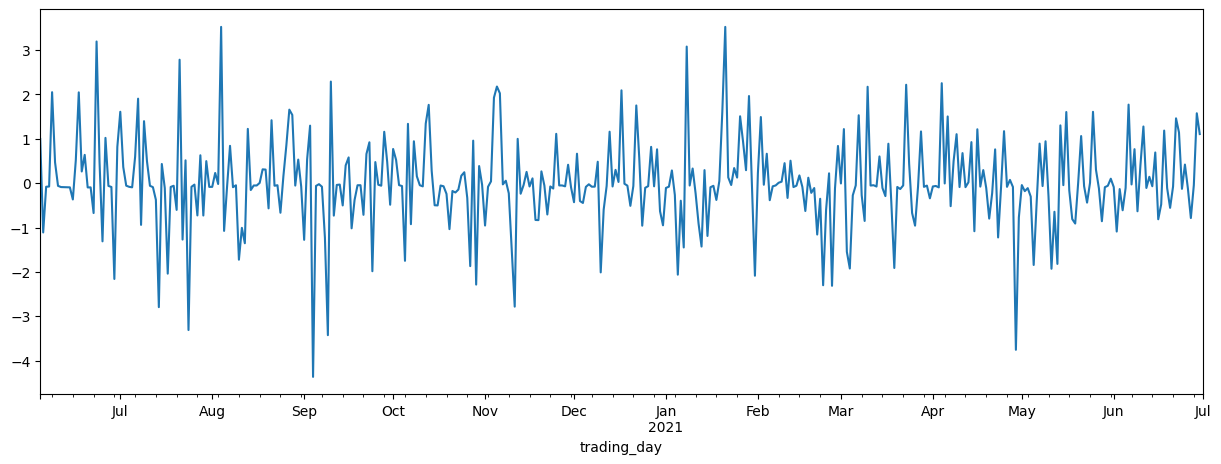

In [85]:
msft_estacionario = garch57_resid.copy()
msft_estacionario.plot(figsize=(15,5))

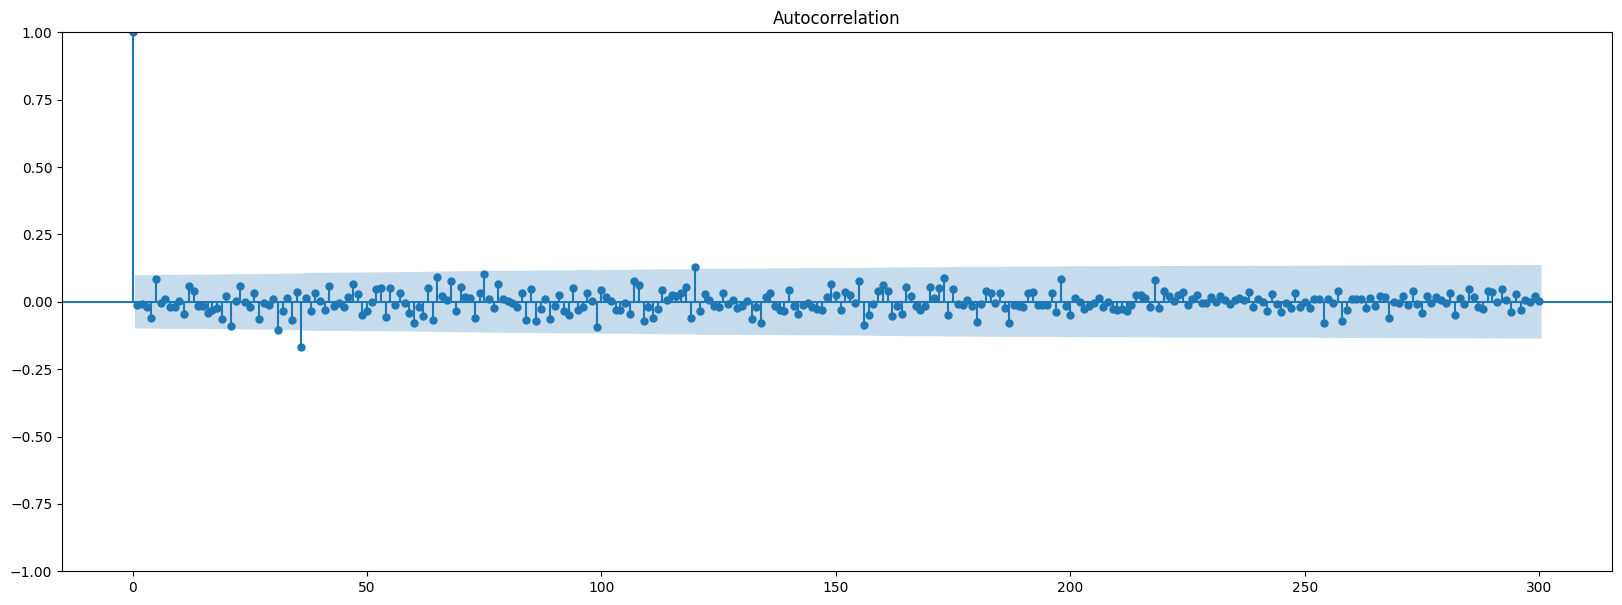

In [88]:
tsaplots.plot_acf(garch57_resid.dropna(), lags=300)
plt.show()

## Predicción de la volatilidad

In [89]:
index = msft_estacionario.index
# Revierto el orden del índice para que el cero corresponda al dato más antiguo (first obs)
index=index[len(index):None:-1] 
start_loc = 0
end_loc = np.where(index >= '2021-01-01')[0].max()

In [90]:
forecasts = {}
for i in range(60):
    res = modelo_garch57.fit(first_obs = start_loc, last_obs = i + end_loc, disp = 'off')
    temp = res.forecast(horizon=1, reindex=True).variance
    fcast = temp.iloc[i + end_loc - 1]
    forecasts[fcast.name] = fcast
print(' Done!')
pred_variance_expand = pd.DataFrame(forecasts).T

c:\Users\USUARIO\.conda\envs\entorno_AZUL_CLARO_R9\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
c:\Users\USUARIO\.conda\envs\entorno_AZUL_CLARO_R9\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
c:\Users\USUARIO\.conda\envs\entorno_AZUL_CLARO_R9\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


 Done!


In [91]:
forecasts = {}
for i in range(60):
    res = modelo_garch57.fit(first_obs=start_loc + i, last_obs=i + end_loc, disp='off')
    temp = res.forecast(horizon=1, reindex=True).variance
    fcast = temp.iloc[i + end_loc - 1]
    forecasts[fcast.name] = fcast
print(' Done!')
pred_variance_fixed = pd.DataFrame(forecasts).T

c:\Users\USUARIO\.conda\envs\entorno_AZUL_CLARO_R9\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


 Done!


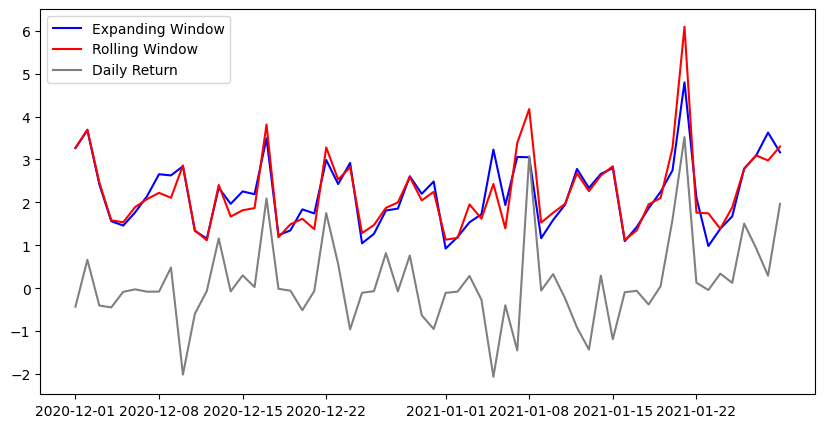

In [92]:
# Calculate volatility from variance forecast with an expanding window
pred_vol_expand = np.sqrt(pred_variance_expand)

# Calculate volatility from variance forecast with a fixed rolling window
pred_vol_fixedwin = np.sqrt(pred_variance_fixed)

# Plot results
plt.figure(figsize=(10,5))

# Plot volatility forecast with an expanding window
plt.plot(pred_vol_expand, color = 'blue', label='Expanding Window')

# Plot volatility forecast with a fixed rolling window
plt.plot(pred_vol_fixedwin, color = 'red', label='Rolling Window')

plt.plot(msft_estacionario.loc[pred_variance_expand.index], color = 'grey', label='Daily Return')

plt.legend()
plt.show()

## 3<sup>er</sup> activo: CATERPILLAR (CAT)

In [93]:
cat_rent = pd.DataFrame(rentabilidades['CAT']*100)
cat_rent

,CAT
trading_day,
2020-06-03,2.568320
2020-06-04,1.506754
2020-06-05,2.744047
2020-06-06,3.595185
2020-06-07,0.000000
...,...
2021-06-27,-1.381417
2021-06-28,-0.000173
2021-06-29,-0.018319


In [94]:
cat = pd.DataFrame(cartera['CAT'])
cat

,CAT
trading_day,
2020-06-03,124.717785
2020-06-04,126.596975
2020-06-05,130.070855
2020-06-06,134.747143
2020-06-07,134.747143
...,...
2021-06-27,216.310000
2021-06-28,216.309626
2021-06-29,216.270000


<Axes: xlabel='trading_day'>

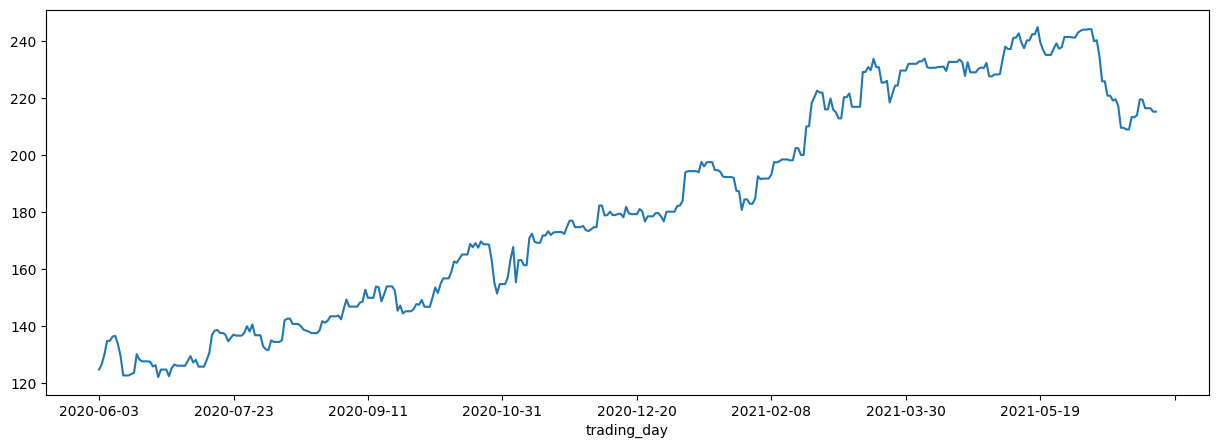

In [95]:
cat['CAT'].plot(figsize=(15,5))

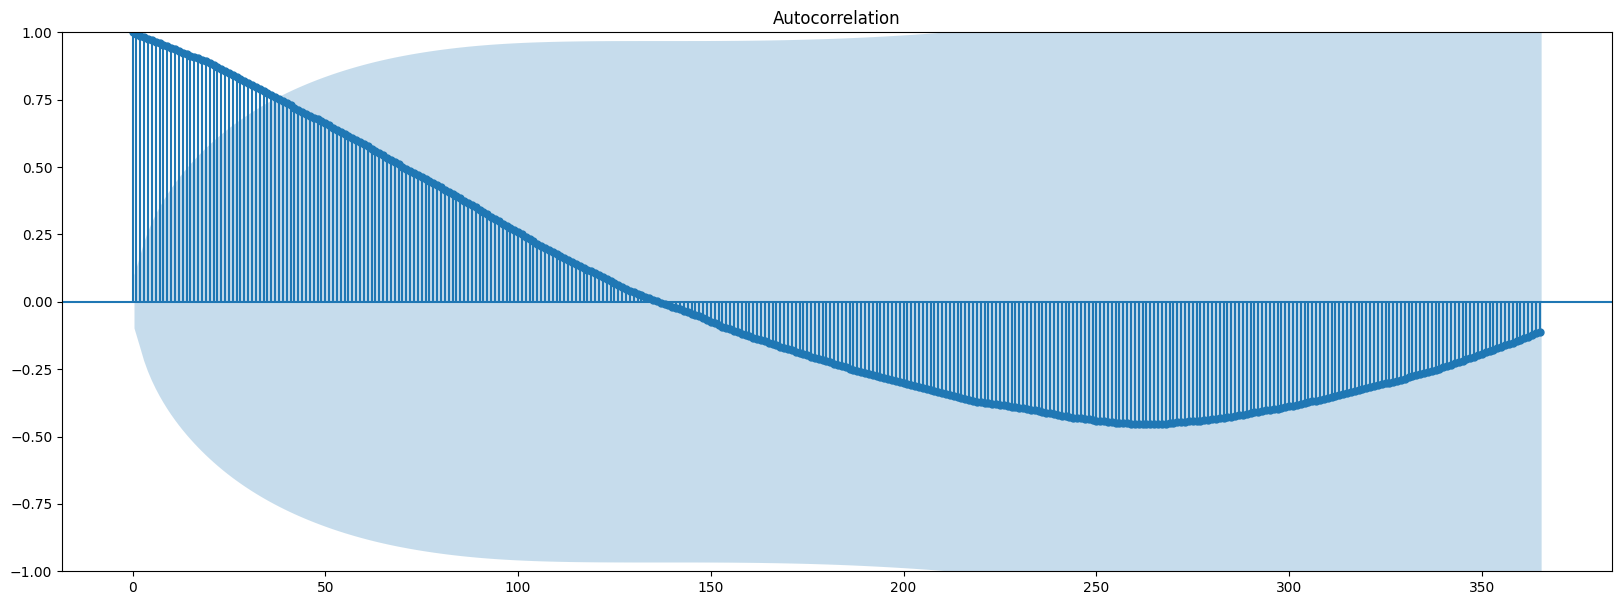

In [100]:
tsaplots.plot_acf(cat['CAT'], lags=365)
plt.show()

NO TIENE SENTIDO USAR SEASONAL DECOMPOSE

<Axes: xlabel='trading_day'>

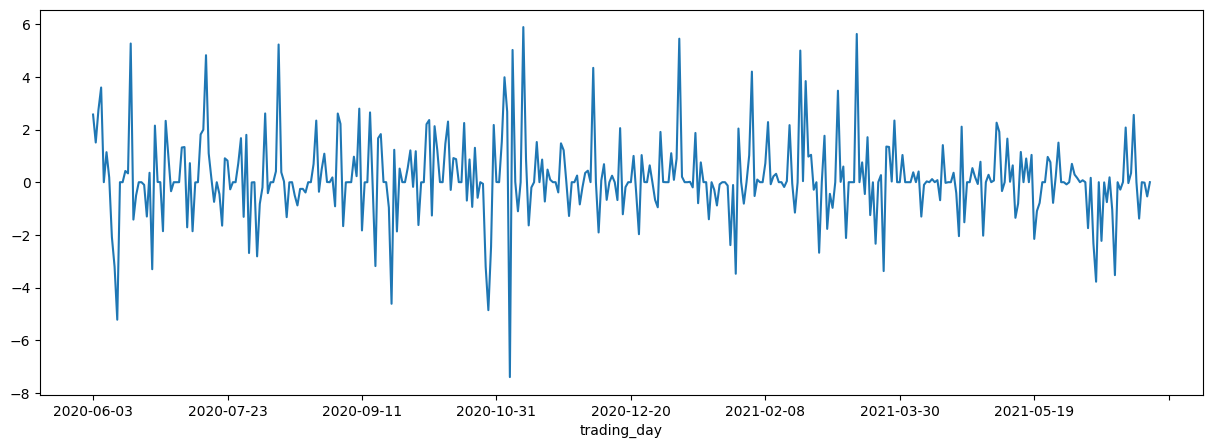

In [101]:
cat_rent['CAT'].plot(figsize=(15,5))

<Axes: xlabel='trading_day'>

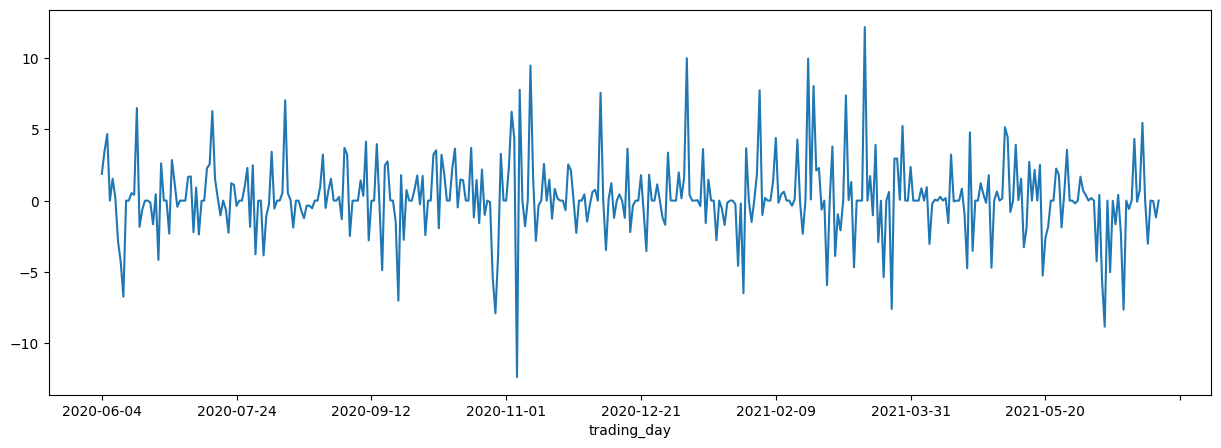

In [104]:
cat['residuo'] = cat['CAT'].diff()
(cat['residuo'].dropna()).plot(figsize=(15,5))

In [106]:
#PASAMOS TESTS DE ESTACIONARIA EN MEDIA

result = adfuller(cat['residuo'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
print(f'Result: The series is {"not " if result[1] > 0.05 else ""}stationary')

ADF Statistic: -19.982831592495526
p-value: 0.0
Critial Values:
   1%, -3.44714244478345
Critial Values:
   5%, -2.8689414326247995
Critial Values:
   10%, -2.5707127699396084
Result: The series is stationary


In [107]:
statistic, p_value, n_lags, critical_values = kpss(cat['residuo'].dropna())
print(f'KPSS Statistic: {statistic}')
print(f'p-value: {p_value}')
print('Critial Values:')
for key, value in critical_values.items():
    print(f'   {key} : {value}')
print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

KPSS Statistic: 0.12226633783473656
p-value: 0.1
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_4128\1473555084.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(cat['residuo'].dropna())


In [108]:
# PASAMOS TEST DE HETEROCEDASTICIDAD

lm_test = het_arch(cat['residuo'].dropna())

print("Resultados del ARCH test:")
print(f"P-valor F: {lm_test[3]:.4f}")

Resultados del ARCH test:
P-valor F: 0.0172


NO ES ESTRICTAMENTE ESTACIONARIA, VAMOS A MODELIZAR LA VOLATILIDAD

In [109]:
vol_cat = cat['residuo'].dropna().mul(cat['residuo'].dropna())

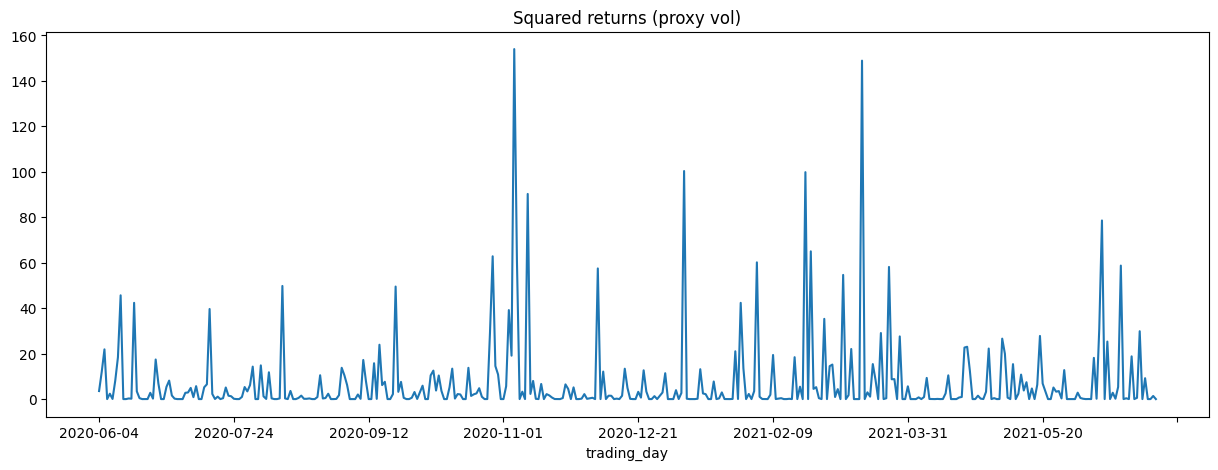

In [110]:
plt.figure(figsize=(15,5)); vol_cat.plot(title='Squared returns (proxy vol)'); plt.show()

In [111]:
cat.index = pd.to_datetime(cat.index)

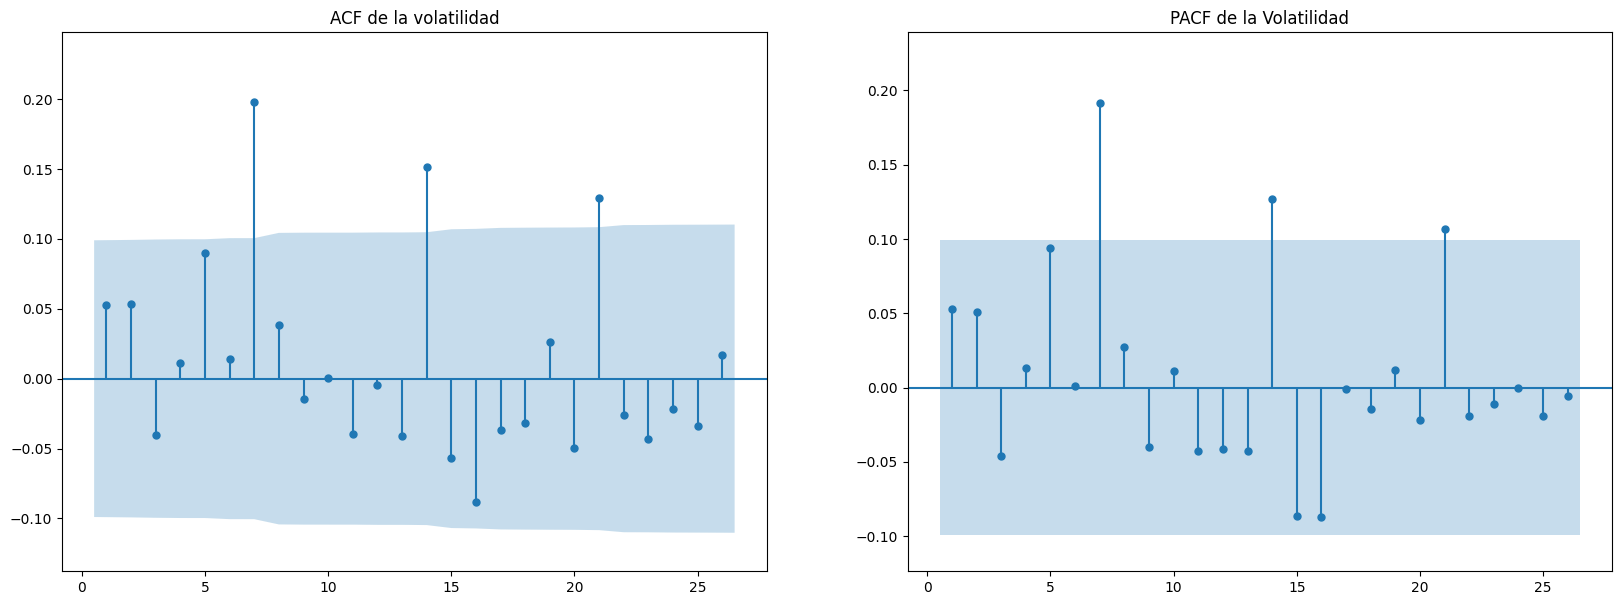

In [112]:
plt.rcParams["figure.figsize"] = (20, 7)

fig, ax = plt.subplots(1,2)

sgt.plot_acf(vol_cat[1:],ax=ax[0],zero = False, auto_ylims=True, title="ACF de la volatilidad")
sgt.plot_pacf(vol_cat[1:],ax=ax[1], zero = False,auto_ylims=True,title="PACF de la Volatilidad");

PROBAMOS ARCH(7) Y GARCH(7,7)

ARCH(7)

In [113]:
modelo_arch7_cat = arch_model(cat.residuo[1:], vol="ARCH", p=7, mean="AR")
resultados_arch7_cat = modelo_arch7_cat.fit(last_obs = cat.index[-1])
resultados_arch7_cat.summary()

Iteration:      1,   Func. Count:     11,   Neg. LLF: 963.3672493770612
Iteration:      2,   Func. Count:     22,   Neg. LLF: 1231.4636751164637
Iteration:      3,   Func. Count:     33,   Neg. LLF: 1045.9895059866858
Iteration:      4,   Func. Count:     44,   Neg. LLF: 233224981.50223395
Iteration:      5,   Func. Count:     55,   Neg. LLF: 2063.8508409849946
Iteration:      6,   Func. Count:     66,   Neg. LLF: 1233.8721130145832
Iteration:      7,   Func. Count:     78,   Neg. LLF: 933.3437592316023
Iteration:      8,   Func. Count:     89,   Neg. LLF: 924.6321716918105
Iteration:      9,   Func. Count:    100,   Neg. LLF: 921.4027797141075
Iteration:     10,   Func. Count:    110,   Neg. LLF: 920.8195717328438
Iteration:     11,   Func. Count:    120,   Neg. LLF: 920.7917355380678
Iteration:     12,   Func. Count:    130,   Neg. LLF: 920.7886114314074
Iteration:     13,   Func. Count:    140,   Neg. LLF: 920.788402382125
Iteration:     14,   Func. Count:    150,   Neg. LLF: 920.78

<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - ARCH Model Results                            
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -920.788
Distribution:                  Normal   AIC:                           1859.58
Method:            Maximum Likelihood   BIC:                           1895.32
                                        No. Observations:                  392
Date:                Sat, Oct 25 2025   Df Residuals:                      391
Time:                        12:47:34   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
Const          0.2785      0.201      1.389      0.165 [ -0.115,  0.672]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          3.8859      1.110      3.502  4.615e-04      [  1.711,  6.061]
alpha[1]       0.0609  9.536e-02      0.638      0.523      [ -0.126,  0.248]
alpha[2]       0.0597  4.700e-02      1.270      0.204   [-3.243e-02,  0.152]
alpha[3]   6.7286e-11      0.199  3.389e-10      1.000      [ -0.389,  0.389]
alpha[4]   4.2041e-11  2.632e-02  1.597e-09      1.000 [-5.159e-02,5.159e-02]
alpha[5]   8.6415e-12  2.840e-02  3.042e-10      1.000 [-5.567e-02,5.567e-02]
alpha[6]       0.0369  8.893e-02      0.415      0.678      [ -0.137,  0.211]
alpha[7]       0.3629      0.167      2.175  2.964e-02    [3.585e-02,  0.690]
=============================================================================

Covariance estimator: robust
"""

GARCH(7,7)

In [130]:
modelo_garch77_cat = arch_model(cat.residuo[1:], vol="GARCH", p=7, q=7, mean='AR')
resultados_garch77_cat = modelo_garch77_cat.fit(last_obs = cat.index[-1])
resultados_garch77_cat.summary()

Iteration:      1,   Func. Count:     18,   Neg. LLF: 969.3864483922798
Iteration:      2,   Func. Count:     36,   Neg. LLF: 1300.2796612694287
Iteration:      3,   Func. Count:     54,   Neg. LLF: 1434.451910173093
Iteration:      4,   Func. Count:     72,   Neg. LLF: 1936.3865819238176
Iteration:      5,   Func. Count:     90,   Neg. LLF: 1169.4427740850183
Iteration:      6,   Func. Count:    109,   Neg. LLF: 966.0471512105539
Iteration:      7,   Func. Count:    127,   Neg. LLF: 1207.4355983686337
Iteration:      8,   Func. Count:    145,   Neg. LLF: 930.4649028500461
Iteration:      9,   Func. Count:    163,   Neg. LLF: 917.7196989043225
Iteration:     10,   Func. Count:    180,   Neg. LLF: 929.1280887899047
Iteration:     11,   Func. Count:    198,   Neg. LLF: 914.2974623670077
Iteration:     12,   Func. Count:    215,   Neg. LLF: 905.3783286619885
Iteration:     13,   Func. Count:    232,   Neg. LLF: 2148.1894262447177
Iteration:     14,   Func. Count:    252,   Neg. LLF: 956.6

c:\Users\USUARIO\.conda\envs\entorno_AZUL_CLARO_R9\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - GARCH Model Results                           
==============================================================================
Dep. Variable:                residuo   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -850.468
Distribution:                  Normal   AIC:                           1732.94
Method:            Maximum Likelihood   BIC:                           1796.48
                                        No. Observations:                  392
Date:                Sat, Oct 25 2025   Df Residuals:                      391
Time:                        12:54:39   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const      2.3202e-03  1.504e-02      0.154      0.877 [-2.716e-02,3.180e-02]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      3.0461e-07  8.880e-02  3.430e-06      1.000      [ -0.174,  0.174]
alpha[1]   1.8893e-06  2.609e-03  7.241e-04      0.999 [-5.112e-03,5.116e-03]
alpha[2]   2.4904e-06  2.941e-03  8.468e-04      0.999 [-5.761e-03,5.766e-03]
alpha[3]   2.8803e-06  2.743e-03  1.050e-03      0.999 [-5.373e-03,5.378e-03]
alpha[4]   1.8613e-06  1.191e-03  1.563e-03      0.999 [-2.333e-03,2.336e-03]
alpha[5]   7.0982e-03  2.617e-02      0.271      0.786 [-4.419e-02,5.839e-02]
alpha[6]   4.7569e-06  1.003e-03  4.740e-03      0.996 [-1.962e-03,1.972e-03]
alpha[7]       0.2074  9.216e-02      2.250  2.443e-02    [2.676e-02,  0.388]
beta[1]    1.4228e-06  9.112e-03  1.561e-04      1.000 [-1.786e-02,1.786e-02]
beta[2]    2.7872e-06  3.321e-03  8.393e-04      0.999 [-6.506e-03,6.511e-03]
beta[3]    2.5274e-04  7.501e-03  3.370e-02      0.973 [-1.445e-02,1.495e-02]
beta[4]    2.3764e-06  2.691e-03  8.830e-04      0.999 [-5.272e-03,5.277e-03]
beta[5]    1.5267e-07  2.563e-02  5.956e-06      1.000 [-5.024e-02,5.024e-02]
beta[6]    4.2601e-06  2.508e-03  1.699e-03      0.999 [-4.911e-03,4.919e-03]
beta[7]        0.7855  7.993e-02      9.828  8.530e-23      [  0.629,  0.942]
=============================================================================

Covariance estimator: robust
WARNING: The optimizer did not indicate successful convergence. The message was Positive directional derivative for linesearch.
See convergence_flag.

"""

In [132]:
arch7_resid_cat = resultados_arch7_cat.std_resid
garch77_resid_cat = resultados_garch77_cat.std_resid

In [133]:
lm_test = het_arch(arch7_resid_cat.dropna())[3]
print(f"P-valor F de ARCH(7): {lm_test:.4f}")

lm_test = het_arch(garch77_resid_cat.dropna())[3]
print(f"P-valor F de GARCH(7,7): {lm_test:.4f}")

P-valor F de ARCH(7): 0.9210
P-valor F de GARCH(7,7): 0.9533


NOS QUEDAMOS CON ARCH(7), ESTÁ EXPLICADO EN EL INFORME

<Axes: xlabel='trading_day'>

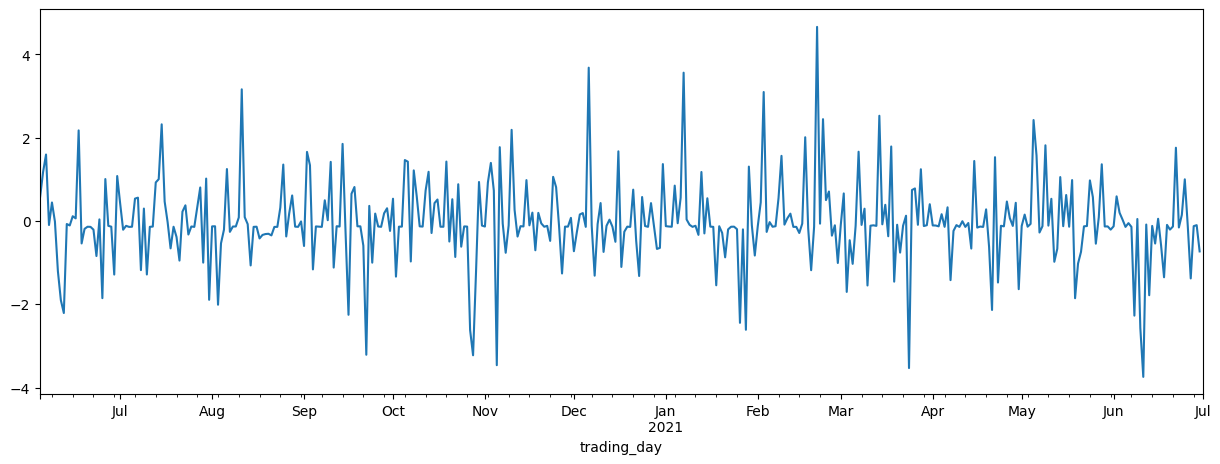

In [134]:
cat_estacionario = arch7_resid_cat.copy()
cat_estacionario.plot(figsize=(15,5))

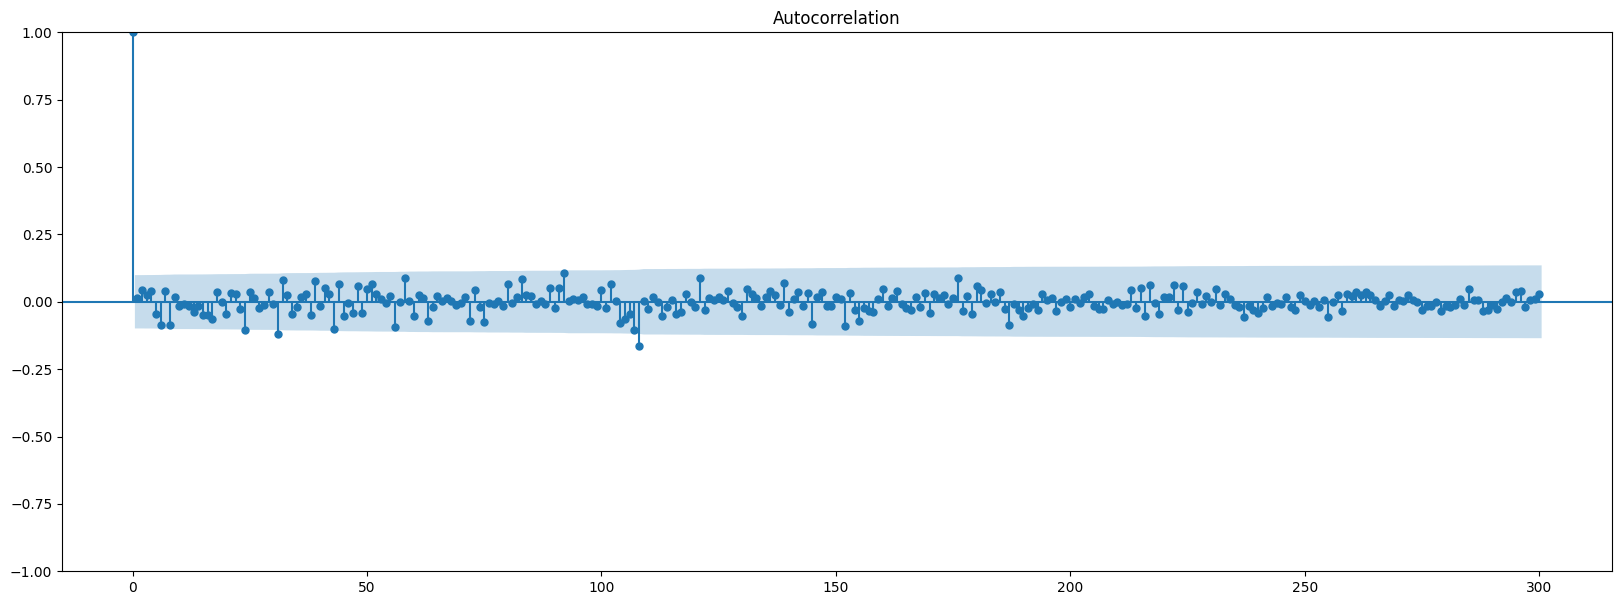

In [135]:
tsaplots.plot_acf(cat_estacionario.dropna(), lags=300)
plt.show()

## Predicción de la volatilidad

In [139]:
index = cat_estacionario.index
# Revierto el orden del índice para que el cero corresponda al dato más antiguo (first obs)
index=index[len(index):None:-1] 
start_loc = 0
end_loc = np.where(index >= '2021-01-01')[0].max()

In [140]:
forecasts = {}
for i in range(60):
    res = modelo_arch7_cat.fit(first_obs = start_loc, last_obs = i + end_loc, disp = 'off')
    temp = res.forecast(horizon=1, reindex=True).variance
    fcast = temp.iloc[i + end_loc - 1]
    forecasts[fcast.name] = fcast
print(' Done!')
pred_variance_expand = pd.DataFrame(forecasts).T

 Done!


In [141]:
forecasts = {}
for i in range(60):
    res = modelo_arch7_cat.fit(first_obs=start_loc + i, last_obs=i + end_loc, disp='off')
    temp = res.forecast(horizon=1, reindex=True).variance
    fcast = temp.iloc[i + end_loc - 1]
    forecasts[fcast.name] = fcast
print(' Done!')
pred_variance_fixed = pd.DataFrame(forecasts).T

 Done!


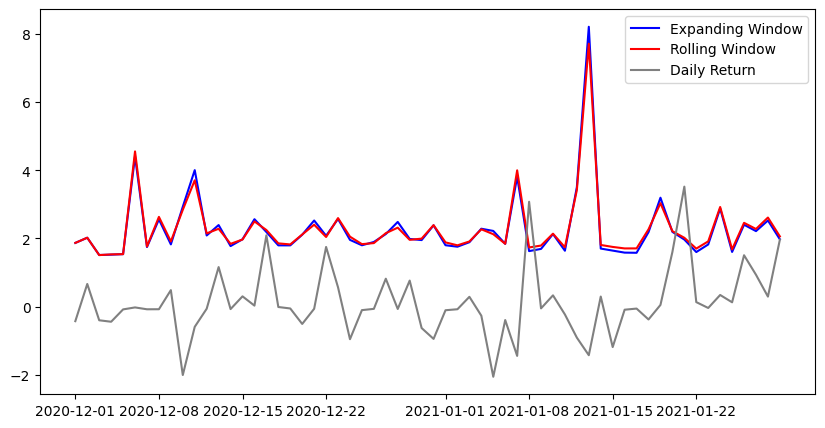

In [142]:
# Calculate volatility from variance forecast with an expanding window
pred_vol_expand = np.sqrt(pred_variance_expand)

# Calculate volatility from variance forecast with a fixed rolling window
pred_vol_fixedwin = np.sqrt(pred_variance_fixed)

# Plot results
plt.figure(figsize=(10,5))

# Plot volatility forecast with an expanding window
plt.plot(pred_vol_expand, color = 'blue', label='Expanding Window')

# Plot volatility forecast with a fixed rolling window
plt.plot(pred_vol_fixedwin, color = 'red', label='Rolling Window')

plt.plot(msft_estacionario.loc[pred_variance_expand.index], color = 'grey', label='Daily Return')

plt.legend()
plt.show()